# eCommerce Customer and Sales Analytics

Olist capstone: customer segmentation and observed-sales forecasting.

This is the project's **only analysis notebook**. Read and run it from top to bottom using the shared AIM_PGD `.venv` kernel. Utilities remain in `../scripts/`; reusable implementation may go in `../src/` when warranted. Keep all analytical explanations, findings, and decisions here. The final report and decks will be derived from this notebook.

**Current state:** Step 1 initial framing and Step 2 focused cleaning, consolidation, and EDA are implemented. Step 3 prepares B/C features with correlation-based selection and PCA; A is retired. Step 4 contains evaluated models and daily/weekly forecasts. Step 5 adds explanations, limitations, and a geographic disparity audit; sensitive-group fairness remains unmeasurable with the available fields. Step 6 provides two 10-slide decks. Other final-report chapters and remaining validation gaps are still pending.

| Section | Purpose | Status |
| --- | --- | --- |
| [1. Problem understanding and framing](#step-1) | Business problem, task types, primary metrics, business KPIs | Written framing complete; data-dependent choices provisional |
| [2. Connect, clean, and explore](#step-2) | Load three relevant tables, clean, connect, and explore | Connected transaction table and simple EDA implemented |
| [3. Preparation, EDA, and features](#step-3) | Cleaning, historical features, feature selection, dimensionality reduction | B/C preparation implemented |
| [4. Model implementation](#step-4) | Trained models, comparisons, and saved artifacts | Implemented |
| [5. Ethical AI and bias auditing](#step-5) | Model explanations, limitations, disparities, and mitigations | Implemented; sensitive-group data gap |
| [6. Final presentation and communication](#step-6) | Technical and business decks | Two 10-slide PowerPoints + PDFs |
| [7. Observed-sales forecasting (C)](#step-7) | Follow-up interpretation of Step 4 forecasts | Pending |
| [8. Earlier fairness placeholder](#step-8) | Work consolidated into Step 5 | See Step 5 |
| [9. Conclusions and reproducibility](#step-9) | Integrated findings, ROI scenarios, model reloads, report/deck evidence | Planned |

[Project brief](../docs/PROJECT_BRIEF.md) | [Rubric tracker](../docs/RUBRIC_ALIGNMENT.md) | [Status](../docs/STATUS.md)

<a id="step-1"></a>

# Step 1: Problem Understanding and Framing

> **Scope update:** B and C are the active modeling tasks. A below records the original framing and is superseded by the decision at the end of Step 2. Classification metrics and deliverables are no longer required for this project.

## 1. Project and business problem

**eCommerce Customer and Sales Analytics: Segmentation, Repeat Purchases, and Demand Forecasting**

An eCommerce management team needs evidence for two related decisions: how to understand and plan for different customer groups, and how to anticipate future product sales. Treating all customers alike can obscure differences in purchasing behavior; relying on recent sales alone may produce poor planning forecasts. These are the business motivations for the study, not measured losses or claims about Olist's internal operations.

Using Olist's historical marketplace transactions, this project will:

1. **A — Predict repeat purchases:** estimate whether an existing customer will place another approved order in a defined future period, supporting customer planning and ranked customer analysis.
2. **B — Segment customers:** identify interpretable purchasing-behavior groups so marketing can understand who buys, how often, and at what spending levels.
3. **C — Forecast observed sales:** estimate future weekly product sales to support operations discussions about expected sales volumes and planning uncertainty.

The intended audience is an eCommerce management team spanning marketing/customer analytics and inventory/operations. The outputs support decisions; they do not establish that a marketing offer causes a purchase or that a forecast alone yields optimal inventory. Olist is the historical data source, not a claimed client or business partner.


## 2. Data context and observed starting facts

Source: [Olist Brazilian E-Commerce Public Dataset, version 2](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/versions/2). Local provenance and hashes are in [DATA_MANIFEST.json](../docs/DATA_MANIFEST.json).

A reproducible, read-only framing check produced:

| Measure | Observed value |
| --- | ---: |
| Order rows | 99,441 |
| Distinct customer_unique_id values associated with orders | 96,096 |
| Customers with more than one distinct order across the full recorded history | 2,997 (3.12%) |
| Orders with an approval timestamp | 99,281 |
| Orders without an approval timestamp | 160 |
| Customers with more than one timestamped approved order | 2,948 |
| Order-item rows | 112,650 |
| Distinct products appearing in order items | 32,951 |

Recorded purchase timestamps span 2016-09-04 through 2018-10-17. These endpoints do not establish continuous/complete coverage. The item table has no explicit quantity column, so the initial sales measure is a count of item records, not an assumed quantity field.

These are descriptive full-history counts across recorded statuses. **3.12% is not the prevalence of the future 90-day classification label.** Cohort-specific prevalence, usable date ranges, cancellations, item semantics, and period completeness belong to Step 2. This small context check is not a completed data-quality or feasibility audit and did not select models using held-out outcomes.


> **Scope update:** B and C are the active modeling tasks. A below records the original framing and is superseded by the decision at the end of Step 2. Classification metrics and deliverables are no longer required for this project.

## 3. Task types, units, and working targets

The three tasks share data preparation but have different targets and evaluation rules. They are not recommendation or anomaly-detection tasks: we are neither recommending individual items nor predicting fraud/outliers.

| Module | Task type and reason | Unit of analysis | Working output/target |
| --- | --- | --- | --- |
| A | Binary classification: a defined future event either occurs or does not | One existing customer at one scoring cutoff t | Probability of at least one new approved order in (t, t + 90 days] |
| B | Unsupervised clustering: there are no ground-truth customer segment labels | One eligible customer's history at a fixed cutoff t | Segment assignment and profile from historical recency, frequency, spending, and suitable additional features |
| C | Time-series forecasting, implemented as numeric regression where appropriate | One eligible product, forecast origin, and future calendar week | Nonnegative forecast of approved-order item-record count for each of the next four complete weeks |

**A/B cohort:** use customer_unique_id for identity; customer_id joins customers to orders. Working definition of a qualifying event is an order with a nonmissing order_approved_at, observed at that timestamp. An existing customer has at least one such event by t. Features use timestamps at or before t; A's label uses only later events. Count distinct order_id values for frequency. Exclude right-censored cutoffs without a complete 90-day outcome window rather than labeling them negative.

**Approval is a working operational definition, not a completed-sale guarantee.** Missing approval timestamps and inconsistent chronology require audit. Final delivery/cancellation status may not have been known at t, so do not filter historical predictors using future status. Distinguish subsequently canceled/returned orders in limitations and sensitivity analysis if supported. If this definition changes after the audit, document the revision before fitting models or inspecting final evaluation outcomes.

**C cohort and target:** join item records to timestamped approved orders with validated cardinality. Count records per product/week using approval time, with Monday-start weeks and the next four full weeks following the scoring week. Audit timestamp semantics, duplicates, and coverage before freezing this contract. Missing observations are not automatically zero sales. Select eligible products from development history only. Category-level aggregation is a possible scope adjustment to discuss if product histories are too sparse; it is not silently substituted.

The 90-day horizon and four-week forecast are current planning assumptions. Data feasibility may change them. The forecasting target represents sales observed in the sampled marketplace; it does not measure stockouts, lost demand, seller-wide demand, or sales elsewhere.


> **Scope update:** B and C are the active modeling tasks. A below records the original framing and is superseded by the decision at the end of Step 2. Classification metrics and deliverables are no longer required for this project.

## 4. Primary technical metrics and success rules

| Module | Primary target metric | Why this metric | Baselines and desired outcome |
| --- | --- | --- | --- |
| A | **Average precision (AP), maximize** | Evaluates positive-event ranking through precision and recall; useful when repeat outcomes may be uncommon | Compare against constant training-prevalence scores and a recency ranking on identical eligible evaluation cohorts. Target AP above both references, with variability reported across time folds |
| B | **Mean silhouette score, maximize** | Measures within-cluster cohesion versus separation when true segment labels are unavailable | Compare with an interpretable RFM segmentation in the same fixed feature space/sample. Seek positive separation and improvement over the reference, subject to stability, group sizes, and readable business profiles |
| C | **Mean absolute error (MAE), minimize** | Gives average forecast error in the same units as the sales-count target and is straightforward to explain | Compare against last-complete-week naive forecasts and a trailing-four-complete-week mean. Target lower MAE than the better reference on the same products, forecast origins, and horizons |

These are prospective success criteria, not achieved results. A failure to beat a baseline is a valid finding to report, not a reason to alter the final test set or conceal a result. No arbitrary accuracy or guaranteed financial-uplift threshold is imposed.

### Metric definitions and evaluation details

- **AP:** sum over precision-recall thresholds of (change in recall x precision). Use average_precision_score, not an unspecified trapezoidal PR-AUC. Constant-score AP equals positive prevalence in the evaluated cohort when both classes are represented. That prevalence must be measured separately for each evaluation period; never substitute the 3.12% full-history statistic. ROC-AUC and accuracy are secondary diagnostics, with accuracy accompanied by a majority-class baseline.
- **Silhouette:** for an observation, (b - a) / max(a, b), where a is mean within-cluster distance and b is the minimum mean distance to another cluster; average across observations. Use the same training-defined transformed feature space and reproducible sample for comparisons. Scores across different PCA spaces are not directly comparable. Flag single-cluster solutions as invalid and disclose any excluded noise points/coverage. Higher silhouette alone is not proof of business utility.
- **MAE:** mean absolute difference between forecast and observed count. Primary aggregation gives each eligible product-origin-horizon observation equal weight in a common four-week panel. Also report per-product and per-horizon MAE, RMSE (large-error sensitivity), and signed bias = mean(forecast - actual). Report data coverage so dropping difficult series does not masquerade as improvement.
- **B stability:** compare repeated fits on common evaluation observations under fixed seeds/resamples using adjusted Rand index where assignments are available; report the distribution and profile consistency. Model/cluster-count selection should balance this evidence with silhouette and segment sizes; there is no universal silhouette threshold that establishes valid segments.
- **Evaluation:** select splits, hyperparameters, feature selection, scaling, PCA, calibration, and decision thresholds on development data only. Train labels must be fully observed before a later scoring cutoff. Use chronological forecast origins; protect the final period. Repeat-customer reuse reflects scoring existing customers, not unseen-customer generalization. Step 2 will freeze actual dates after checking coverage, before model comparisons begin.

Metric references: [average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html), [silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html), and [MAE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html). These define the metrics; our business use and comparison rules are project design decisions.


> **Scope update:** B and C are the active modeling tasks. A below records the original framing and is superseded by the decision at the end of Step 2. Classification metrics and deliverables are no longer required for this project.

## 5. Business goals and indicative KPIs

The project aims to support better customer and sales planning. At this stage, these goals give us a direction; detailed measurement rules will follow the data audit.

| Project analysis | Business direction | Indicators we can explore |
| --- | --- | --- |
| A. Repeat-purchase prediction | Help marketing identify customers more likely to buy again | Repeat-purchase rate among customers the model prioritizes |
| B. Customer segmentation | Understand customer groups and suggest relevant marketing approaches | Customer group sizes, purchasing patterns, and spending shares |
| C. Sales forecasting | Help operations anticipate sales and plan ahead | Forecast errors compared with a simple baseline, including over- or under-forecasting |

We will choose exact KPI calculations and targets in the evaluation stage, before comparing models. Any discussion of revenue gains or cost savings will be clearly labeled as a scenario unless supported by actual business evidence.

> **Scope update:** B and C are the active modeling tasks. A below records the original framing and is superseded by the decision at the end of Step 2. Classification metrics and deliverables are no longer required for this project.

## 6. Scope, risks, and analytical boundaries

- Keep B and C in scope; A is retired from prediction, with one shared data foundation and separate evaluation protocols.
- Sparse repeat events may limit A and frequency-driven segments in B. Many products may have sparse histories for C. Resolve support with the audit before selecting models or promising targets.
- Explain model behavior and audit supported subgroups later. Olist lacks explicit age/gender/race attributes in the recorded schema; geographic disparity analysis does not close the rubric's sensitive-group gap.
- Do not use customer/product identifiers as numeric predictors or infer protected demographics. Keep raw files unchanged.
- Models, scores, mitigation results, decks, and public GitHub publication are future work. Step 1 establishes the initial direction and technical success rules; detailed business measurement follows the data audit.


## 7. Connection to the learning program

We use **Program Module 1** to mean **Overview of AI and ML**, following the course description provided. It gives us the foundation for defining a business problem and choosing a suitable machine-learning task.

That foundation supports the first three capstone steps:

1. **Problem framing:** decide what we want to learn and why it matters.
2. **Data understanding:** check whether the available data can answer our questions.
3. **Data preparation:** prepare the data for analysis and modeling.

Within this project, **A, B, and C** label our three analyses: repeat-purchase prediction, customer segmentation, and sales forecasting.

**Framing outcome:** initial problem framing is complete. The data audit follows in Step 2 below. Detailed business KPI definitions will follow during evaluation design.

In [1]:
from pathlib import Path
import json
import sys

# 1. Find the project folder, depending on where Jupyter started.
working_folder = Path.cwd()

if working_folder.name == "5.0 Final Project":
    project_root = working_folder
elif working_folder.name == "notebooks":
    project_root = working_folder.parent
else:
    # Jupyter may have started in the parent AIM_PGD workspace.
    project_root = working_folder / "5.0 Final Project"

if not (project_root / "scripts" / "summarize_framing_data.py").is_file():
    raise FileNotFoundError(
        "Open this notebook from AIM_PGD, 5.0 Final Project, or its notebooks folder."
    )

# 2. Let Python find our project utilities, then import the summary function.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.summarize_framing_data import summarize

# 3. Calculate the data summary and display it with readable indentation.
context_counts = summarize()
print(json.dumps(context_counts, indent=2))

{
  "dataset_handle": "olistbr/brazilian-ecommerce/versions/2",
  "scope": "Full-history descriptive counts; not 90-day future-label prevalence or a full audit.",
  "orders": 99441,
  "unique_customers": 96096,
  "customers_with_multiple_orders": 2997,
  "repeat_customer_pct_full_history": 3.1187562437562435,
  "approved_orders": 99281,
  "customers_with_approved_orders": 95997,
  "customers_with_multiple_approved_orders": 2948,
  "missing_approval_timestamp": 160,
  "purchase_timestamp_min": "2016-09-04 21:15:19",
  "purchase_timestamp_max": "2018-10-17 17:30:18",
  "item_rows": 112650,
  "products_with_item_rows": 32951,
  "explicit_quantity_column_present": false
}


<a id="step-2"></a>

# Step 2: Connect, Clean, and Explore the Data

We need a table that connects **customers, orders, products, dates, and prices**. This will support repeat-purchase prediction, customer segmentation, and sales forecasting.

We will use three files from our [recorded Olist download](../docs/DATA_MANIFEST.json):

| Table | What we need from it |
| --- | --- |
| Orders | Order ID, customer ID, and approval date |
| Customers | The customer's identity across different orders |
| Order items | Products and prices within each order |

Other tables can be added later if an analysis needs them. The original CSV files stay unchanged.

## 2.1 Load only the columns we need

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# project_root was set in Step 1.
raw = project_root / "data" / "raw" / "olist"

orders = pd.read_csv(
    raw / "olist_orders_dataset.csv",
    usecols=["order_id", "customer_id", "order_approved_at"],
    dtype="string",
)
customers = pd.read_csv(
    raw / "olist_customers_dataset.csv",
    usecols=["customer_id", "customer_unique_id"],
    dtype="string",
)
items = pd.read_csv(
    raw / "olist_order_items_dataset.csv",
    usecols=["order_id", "order_item_id", "product_id", "price"],
    dtype="string",
)

# Convert dates and numbers so we can calculate with them.
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")
items["order_item_id"] = pd.to_numeric(items["order_item_id"], errors="coerce")
items["price"] = pd.to_numeric(items["price"], errors="coerce")

tables = {"orders": orders, "customers": customers, "items": items}
display(pd.DataFrame({
    name: {"rows": len(table), "columns": len(table.columns)}
    for name, table in tables.items()
}).T)

# Show exactly which source columns we kept or excluded with usecols.
source_files = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "items": "olist_order_items_dataset.csv",
}
column_selection = []
for name, filename in source_files.items():
    source_columns = pd.read_csv(raw / filename, nrows=0).columns
    kept_columns = list(tables[name].columns)
    excluded_columns = [column for column in source_columns if column not in kept_columns]
    column_selection.append({
        "table": name,
        "kept_columns": ", ".join(kept_columns),
        "excluded_columns": ", ".join(excluded_columns),
    })

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(column_selection))


,rows,columns
orders,99441,3
customers,99441,2
items,112650,4


,table,kept_columns,excluded_columns
0,orders,"order_id, customer_id, order_approved_at","order_status, order_purchase_timestamp, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date"
1,customers,"customer_id, customer_unique_id","customer_zip_code_prefix, customer_city, customer_state"
2,items,"order_id, order_item_id, product_id, price","seller_id, shipping_limit_date, freight_value"


**Why exclude these columns for now?** The table above shows columns omitted during loading; the original files still contain them.

- **Orders:** we use approval time for the current event definition. Final status and delivery outcomes may reveal information unavailable at an earlier prediction date. Purchase time and estimated delivery could support later checks, so they are not considered useless.
- **Customers:** ZIP code, city, and state are not needed for our initial purchase/spending features. They may be useful later for geographic comparisons.
- **Items:** seller, shipping deadline, and freight are outside the initial product-sales and item-spending definitions. Freight would be needed to study total paid/shipping costs.

These are scope choices, not feature-importance results. We can add a column back when an analysis needs it.

## 2.2 Find the connections

Shared column names reveal the connections. We will use **customer_id** to connect orders to customers, then **order_id** to connect items to those orders.

The same `customer_unique_id` can appear across several orders. We use that field later to recognize repeat customers.

In [3]:
# Look for column names that appear in each pair of tables.
connections = []
for left_name, right_name in [("orders", "customers"), ("orders", "items"), ("customers", "items")]:
    common_columns = sorted(set(tables[left_name].columns) & set(tables[right_name].columns))
    connections.append({
        "table_1": left_name,
        "table_2": right_name,
        "shared_columns": ", ".join(common_columns) or "None: connect through orders",
    })

display(pd.DataFrame(connections))

,table_1,table_2,shared_columns
0,orders,customers,customer_id
1,orders,items,order_id
2,customers,items,None: connect through orders


## 2.3 Remove missing and duplicate records

All the columns we selected are needed. We remove rows with missing values in these columns and remove exact duplicate rows. We also remove nonpositive prices or item sequence numbers.

An approval date is needed because our project counts **approved orders**. Approval does not guarantee delivery.

In [4]:
# Record the number of rows removed from each selected table.
cleaning_summary = []
clean_tables = {}

for name, table in tables.items():
    without_nulls = table.dropna()
    clean_table = without_nulls.drop_duplicates()
    cleaning_summary.append({
        "table": name,
        "starting_rows": len(table),
        "missing_rows_removed": len(table) - len(without_nulls),
        "duplicate_rows_removed": len(without_nulls) - len(clean_table),
        "remaining_rows": len(clean_table),
    })
    clean_tables[name] = clean_table

orders = clean_tables["orders"]
customers = clean_tables["customers"]
items = clean_tables["items"]

valid_items = (items["price"] > 0) & (items["order_item_id"] >= 1)
print(f"Item rows removed for invalid price or sequence: {(~valid_items).sum():,}")
items = items.loc[valid_items].copy()

display(pd.DataFrame(cleaning_summary))

Item rows removed for invalid price or sequence: 0


,table,starting_rows,missing_rows_removed,duplicate_rows_removed,remaining_rows
0,orders,99441,160,0,99281
1,customers,99441,0,0,99441
2,items,112650,0,0,112650


## 2.4 Build the consolidated DataFrame

Each row in **consolidated_df** will represent **one item in one approved order**.

We first connect orders to customers, then connect items to that result. The `validate` argument checks that a matching order/customer appears only once on the lookup side, preventing accidental row multiplication.

In [5]:
# Attach a persistent customer identity to each approved order.
orders_with_customers = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one",
)
assert orders_with_customers["customer_unique_id"].notna().all()

# Connect each item to its order and customer using the shared order_id.
consolidated_df = items.merge(
    orders_with_customers,
    on="order_id",
    how="inner",
    validate="many_to_one",
)

# Keep only the fields needed for our three analyses.
consolidated_df = consolidated_df[[
    "order_id", "order_item_id", "customer_unique_id",
    "product_id", "order_approved_at", "price",
]].copy()

# One row per item, complete required fields, and no multiplying joins.
assert not consolidated_df.duplicated(["order_id", "order_item_id"]).any()
assert consolidated_df.notna().all().all()
assert len(consolidated_df) == items["order_id"].isin(orders_with_customers["order_id"]).sum()

print(f"Consolidated data: {len(consolidated_df):,} item rows and {len(consolidated_df.columns)} columns.")
print(f"Item rows without a usable approved order: {len(items) - len(consolidated_df):,}")
orders_without_items = (~orders_with_customers["order_id"].isin(consolidated_df["order_id"])).sum()
print(f"Approved orders without item details: {orders_without_items:,}")

display(consolidated_df.head())

Consolidated data: 112,635 item rows and 6 columns.
Item rows without a usable approved order: 15
Approved orders without item details: 629


,order_id,order_item_id,customer_unique_id,product_id,order_approved_at,price
0,00010242fe8c5a6d1ba2dd792cb16214,1,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,2017-09-13 09:45:35,58.9
1,00018f77f2f0320c557190d7a144bdd3,1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,2017-04-26 11:05:13,239.9
2,000229ec398224ef6ca0657da4fc703e,1,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,2018-01-14 14:48:30,199.0
3,00024acbcdf0a6daa1e931b038114c75,1,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,2018-08-08 10:10:18,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,2017-02-04 14:10:13,199.9


Our working table contains just these six columns:

| Column | Meaning and use |
| --- | --- |
| order_id | Order identifier; count distinct orders for purchase frequency |
| order_item_id | Item sequence within an order; together with order_id identifies a row |
| customer_unique_id | Customer identity across orders; used for A/B |
| product_id | Product identifier; used for C |
| order_approved_at | Approval timestamp, with no timezone supplied; determines event timing |
| price | Item price, treated as BRL; excludes freight and is not net profit |

Some approved orders have no item details. Their spending is unknown. We retain **orders_with_customers** for repeat-purchase labels so missing item details do not erase known purchases.

## 2.5 Remove price outliers for EDA

We use the **IQR rule**: calculate the middle 50% of prices, then flag values below Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR.

We remove those rows from **eda_df**, which we will use to inspect typical prices. An unusual price is not necessarily a data error, so **consolidated_df** retains valid transactions for later purchase and sales targets.

Use data before **2 April 2018** for EDA and outlier thresholds. Later data stays available for evaluation; final model splits will be defined in Step 4.

In [6]:
# Keep the exploratory period separate from later evaluation data.
development_end = pd.Timestamp("2018-04-02")
development_df = consolidated_df.loc[
    consolidated_df["order_approved_at"] < development_end
].copy()

q1 = development_df["price"].quantile(0.25)
q3 = development_df["price"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
outliers = ~development_df["price"].between(lower_limit, upper_limit)
eda_df = development_df.loc[~outliers].copy()

display(pd.DataFrame([{
    "lower_price_limit": round(lower_limit, 2),
    "upper_price_limit": round(upper_limit, 2),
    "rows_before": len(development_df),
    "outlier_rows_removed": int(outliers.sum()),
    "rows_after": len(eda_df),
}]))
display(eda_df[["price"]].describe().round(2))

,lower_price_limit,upper_price_limit,rows_before,outlier_rows_removed,rows_after
0,-101.25,275.15,75407,5648,69759


,price
count,69759.0
mean,83.53
std,58.66
min,1.2
25%,38.4
50%,68.9
75%,116.99
max,275.0


## 2.6 Explore the patterns

Three charts give us a starting point:

- **Item prices:** what does typical spending per item look like after the IQR filter?
- **Customer frequency:** how many customers have 1, 2, 3, or 4+ recorded orders?
- **Weekly item sales:** how does recorded sales activity change over time?

For frequency, group by **customer_unique_id** and count distinct **order_id** values. A customer receives a different customer_id for each order, and one order can contain several items, as explained in the [Olist dataset documentation](https://www.kaggle.com/olistbr/brazilian-ecommerce/metadata).

The frequency chart covers approved orders **before 2 April 2018**. It describes recorded purchases within our data, not whether someone will ever buy again. Only the price chart uses the outlier-filtered EDA table.

,customers,share_pct
recorded_orders,,
1,62556,97.00
2,1789,2.77
3,121,0.19
4+,28,0.04


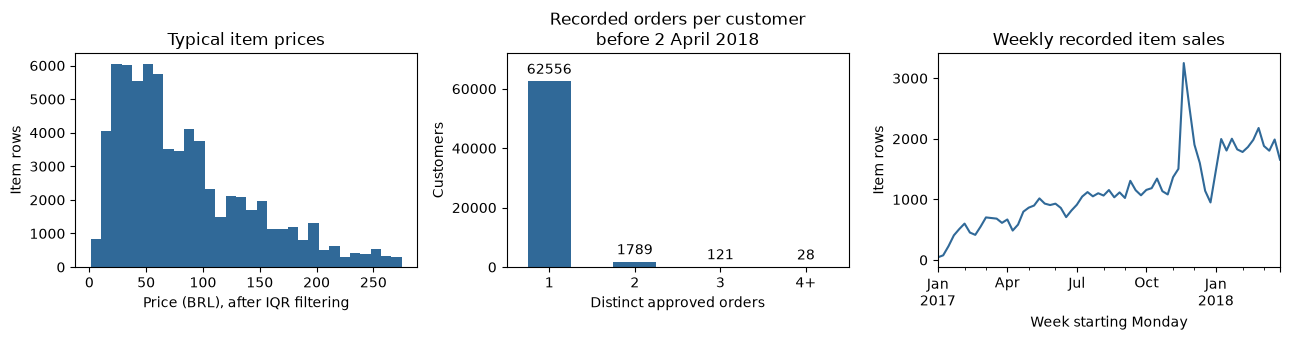

Median item price after IQR filtering: BRL 68.90
Customers with one approved order: 97.0%
Products observed in the development transactions: 22,988
First vs last full-week item count in this overview: 44 vs 1,656


In [7]:
# Count each order once, even when it contains several items.
development_orders = orders_with_customers.loc[
    orders_with_customers["order_approved_at"] < development_end
]
customer_frequency = development_orders.groupby("customer_unique_id")["order_id"].nunique()

# Check that repeated item rows are not being counted as extra orders.
assert customer_frequency.sum() == development_orders["order_id"].nunique()

# Group the small tail as 4+ orders to keep the chart readable.
frequency_counts = customer_frequency.clip(upper=4).value_counts().reindex([1, 2, 3, 4], fill_value=0)
frequency_counts.index = ["1", "2", "3", "4+"]
frequency_summary = frequency_counts.rename("customers").to_frame()
frequency_summary["share_pct"] = (100 * frequency_summary["customers"] / len(customer_frequency)).round(2)
display(frequency_summary.rename_axis("recorded_orders"))

# Use full Monday-start weeks from January 2017 for the sales overview.
sales_start = pd.Timestamp("2017-01-02")
weekly_sales = (
    development_df.loc[development_df["order_approved_at"] >= sales_start]
    .set_index("order_approved_at")
    .resample("W-MON", label="left", closed="left")
    .size()
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(eda_df["price"].to_numpy(dtype=float), bins=30, color="#306998")
axes[0].set(title="Typical item prices", xlabel="Price (BRL), after IQR filtering", ylabel="Item rows")
frequency_counts.plot.bar(ax=axes[1], rot=0, color="#306998")
axes[1].set(
    title="Recorded orders per customer\nbefore 2 April 2018",
    xlabel="Distinct approved orders", ylabel="Customers",
    ylim=(0, frequency_counts.max() * 1.15),
)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3)
weekly_sales.plot(ax=axes[2], color="#306998")
axes[2].set(title="Weekly recorded item sales", xlabel="Week starting Monday", ylabel="Item rows")
fig.tight_layout()

figure_directory = project_root / "reports" / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_directory / "02_simple_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median item price after IQR filtering: BRL {eda_df['price'].median():.2f}")
print(f"Customers with one approved order: {(customer_frequency == 1).mean():.1%}")
print(f"Products observed in the development transactions: {development_df['product_id'].nunique():,}")
print(f"First vs last full-week item count in this overview: {weekly_sales.iloc[0]:,} vs {weekly_sales.iloc[-1]:,}")

**Did customers have enough time to buy again?**

A customer first seen shortly before our cutoff has had less observed time to return. Compare customers first seen fewer than 90 days before the cutoff with those first seen at least 90 days earlier.

Here, "first seen" means the first approved order recorded in this dataset. It is not necessarily the customer's first-ever purchase or signup date.

In [8]:
# Summarize each customer's recorded orders and first observed approval.
customer_observation = development_orders.groupby("customer_unique_id").agg(
    recorded_orders=("order_id", "nunique"),
    first_seen=("order_approved_at", "min"),
)
customer_observation["days_observed"] = (
    development_end - customer_observation["first_seen"]
).dt.days
customer_observation["multiple_orders"] = customer_observation["recorded_orders"] > 1
customer_observation["time_available"] = pd.cut(
    customer_observation["days_observed"],
    bins=[-1, 89, float("inf")],
    labels=["Under 90 days", "90 days or more"],
)

observation_summary = customer_observation.groupby("time_available", observed=True).agg(
    customers=("recorded_orders", "size"),
    customers_with_multiple_orders=("multiple_orders", "sum"),
)
observation_summary["multiple_order_pct"] = (
    100 * observation_summary["customers_with_multiple_orders"]
    / observation_summary["customers"]
).round(2)

assert observation_summary["customers"].sum() == len(customer_frequency)
assert observation_summary["customers_with_multiple_orders"].sum() == (customer_frequency > 1).sum()
display(observation_summary)

,customers,customers_with_multiple_orders,multiple_order_pct
time_available,,,
Under 90 days,20522,403,1.96
90 days or more,43972,1535,3.49


**What this means for our project:** recorded repeats are uncommon. The observation-time groups above have unequal windows, so their percentages are not a common 90-day repeat rate or evidence of permanent churn.

**Scope decision: drop A as a predictive task.** Most customers have only one recorded order. Earlier development checks found 242 repeat purchasers among 26,682 October profiles (0.91%) and 323 among 43,916 January profiles (0.74%) over complete future 90-day windows. These are historical feasibility findings from the retired experiment, not outputs of the current preparation code. The issue is few positive examples, not an incorrect one-row-per-customer structure. Classification is possible, but we are narrowing the project to focus on **B: customer segmentation** and **C: observed-sales forecasting**. Repeat purchasing remains descriptive EDA. This does not guarantee that B or C will perform well; both still need evaluation.

Customer segmentation will consider recency and spending alongside frequency. Sales forecasting will use product-week histories. Step 3 builds these two tables from `consolidated_df`; the price-filtered `eda_df` remains for descriptive charts only.

<a id="step-3"></a>

# Step 3: Preparation, EDA, and Features

**Updated scope:** repeat-purchase prediction (A) has been dropped because there are few observed repeat outcomes. We retain repeat-purchase EDA, but no longer create 90-day labels, train classifiers, or compare AP scores.

This step prepares **B: customer segmentation** and **C: weekly observed-sales forecasting**. Customer profiles still have one row per customer: this is the correct unit for segmentation, regardless of how many item rows appear in their orders.

## 3.1 Build customer profiles for B

Use approved-order history strictly before 2 April 2018. Count distinct orders using `customer_unique_id`; separate order IDs remain separate even if timestamps match. Spending sums available item prices, excluding freight. Approval is not proof of final delivery. Missing item information stays unknown, and valid expensive purchases remain in the feature history.

| Feature | Meaning / unit | Allowed values |
| --- | --- | --- |
| recency_days | Whole days since latest recorded approval | Integer >= 0 |
| order_frequency | Distinct approved orders before cutoff | Integer >= 1 |
| history_days | Whole days since first recorded approval | Integer >= 0 |
| observed_spend | Sum of available item prices, BRL | Positive number or missing |
| avg_order_value | Observed spend / orders with item details, BRL/order | Positive number or missing |
| product_variety | Distinct recorded products | Integer >= 1 or missing |
| spend_coverage | Orders with item details / all approved orders | Fraction from 0 to 1 |
| recency_band | Binned recency | 0-30, 31-90, or 91+ days |


Keep the customer ID as a row key. Coverage and missingness describe data quality; they will not be clustering inputs. Recency bands remain readable profile labels, not extra copies of recency in the model.

In [9]:
import numpy as np

def make_customer_features(cutoff):
    # Start with orders so customers without item details are retained.
    past_orders = orders_with_customers.loc[
        orders_with_customers["order_approved_at"] < cutoff
    ]
    past_items = consolidated_df.loc[consolidated_df["order_approved_at"] < cutoff]

    features = past_orders.groupby("customer_unique_id").agg(
        first_seen=("order_approved_at", "min"),
        last_seen=("order_approved_at", "max"),
        order_frequency=("order_id", "nunique"),
    )
    features["recency_days"] = (cutoff - features.pop("last_seen")).dt.days
    features["history_days"] = (cutoff - features.pop("first_seen")).dt.days

    spending = past_items.groupby("customer_unique_id").agg(
        observed_spend=("price", "sum"),
        product_variety=("product_id", "nunique"),
        known_item_orders=("order_id", "nunique"),
    )
    features = features.join(spending, validate="one_to_one")
    features["avg_order_value"] = features["observed_spend"] / features["known_item_orders"]
    features["spend_coverage"] = (
        features["known_item_orders"].fillna(0) / features["order_frequency"]
    )
    features = features.drop(columns="known_item_orders")
    features["recency_band"] = pd.cut(
        features["recency_days"], [-1, 30, 90, np.inf],
        labels=["0-30 days", "31-90 days", "91+ days"],
    )

    assert features.index.is_unique
    assert features["order_frequency"].sum() == past_orders["order_id"].nunique()
    assert features["spend_coverage"].between(0, 1).all()
    assert np.isclose(features["observed_spend"].sum(), past_items["price"].sum())
    return features

profile_cutoff = development_end
customer_profiles = make_customer_features(profile_cutoff)
display(customer_profiles.head())
display(customer_profiles.describe().round(2))
display(customer_profiles.isna().sum().rename("missing_customers").to_frame())

,order_frequency,recency_days,history_days,observed_spend,product_variety,avg_order_value,spend_coverage,recency_band
customer_unique_id,,,,,,,,
0000f46a3911fa3c0805444483337064,1,387,387,69.0,1.0,69.0,1.0,91+ days
0000f6ccb0745a6a4b88665a16c9f078,1,171,171,25.99,1.0,25.99,1.0,91+ days
0004aac84e0df4da2b147fca70cf8255,1,138,138,180.0,1.0,180.0,1.0,91+ days
00053a61a98854899e70ed204dd4bafe,1,32,32,382.0,2.0,382.0,1.0,31-90 days
0005e1862207bf6ccc02e4228effd9a0,1,393,393,135.0,1.0,135.0,1.0,91+ days


,order_frequency,recency_days,history_days,observed_spend,product_variety,avg_order_value,spend_coverage
count,64494.00,64494.00,64494.00,63953.0,63953.00,63953.0,64494.00
mean,1.03,170.13,171.91,140.6,1.07,136.58,0.99
std,0.21,119.76,120.18,212.36,0.31,205.98,0.09
min,1.00,0.00,0.00,2.29,1.00,2.29,0.00
25%,1.00,69.00,71.00,47.4,1.00,45.9,1.00
50%,1.00,141.00,143.00,89.0,1.00,85.99,1.00
75%,1.00,258.00,261.00,154.9,1.00,149.9,1.00
max,10.00,563.00,563.00,13440.0,13.00,13440.0,1.00


,missing_customers
order_frequency,0
recency_days,0
history_days,0
observed_spend,541
product_variety,541
avg_order_value,541
spend_coverage,0
recency_band,0


## 3.2 Explore customer relationships

Start with two readable comparisons of the development customer profiles, before imputation or scaling. These groups describe observed history; they are not learned customer segments.

**Grouped summary:** compare customers with **1, 2, and 3+ distinct approved orders**. Show group size, missing spending, and median spending, recency, and product variety. Medians skip missing values. Recorded spending may still be incomplete when only some orders have item details.

Higher total spending among frequent purchasers is partly built into the calculation. It is not evidence that encouraging another purchase causes a particular increase in spending.

In [10]:
# Use a copy so descriptive groups do not become clustering inputs.
customer_groups = customer_profiles.copy()
customer_groups["order_group"] = pd.cut(
    customer_groups["order_frequency"],
    bins=[0, 1, 2, float("inf")], labels=["1 order", "2 orders", "3+ orders"],
)
customer_groups["missing_spend"] = customer_groups["observed_spend"].isna()
customer_groups["incomplete_spend"] = customer_groups["spend_coverage"] < 1

order_group_summary = customer_groups.groupby("order_group", observed=False).agg(
    customers=("order_frequency", "size"),
    missing_spend_customers=("missing_spend", "sum"),
    incomplete_spend_customers=("incomplete_spend", "sum"),
    median_spend_brl=("observed_spend", "median"),
    median_recency_days=("recency_days", "median"),
    median_product_variety=("product_variety", "median"),
)
order_group_summary.insert(
    1, "customer_share_pct", 100 * order_group_summary["customers"] / len(customer_groups)
)
display(order_group_summary.round(2))


,customers,customer_share_pct,missing_spend_customers,incomplete_spend_customers,median_spend_brl,median_recency_days,median_product_variety
order_group,,,,,,,
1 order,62556,97.00,536,536,85.9,142.0,1.0
2 orders,1789,2.77,5,28,174.4,127.0,2.0
3+ orders,149,0.23,0,3,280.29,127.0,3.0


**Spending by recency band:** each box shows the middle 50% of recorded customer spending, with a line for the median. Whiskers extend to the furthest observations within 1.5 times the IQR; points beyond them remain visible.

The vertical axis uses a logarithmic scale, labeled in BRL, to keep both typical and high spending readable. No expensive customers are removed. Customers with missing spending are excluded from the boxes and counted in the accompanying table. The plotted counts are shown below each box. Different history lengths and incomplete item records can affect these comparisons.

,customers,plotted_customers,missing_spend_customers,incomplete_spend_customers,median_spend_brl
recency_band,,,,,
0-30 days,7051,7035,16,18,89.9
31-90 days,13851,13780,71,82,89.0
91+ days,43592,43138,454,467,89.0


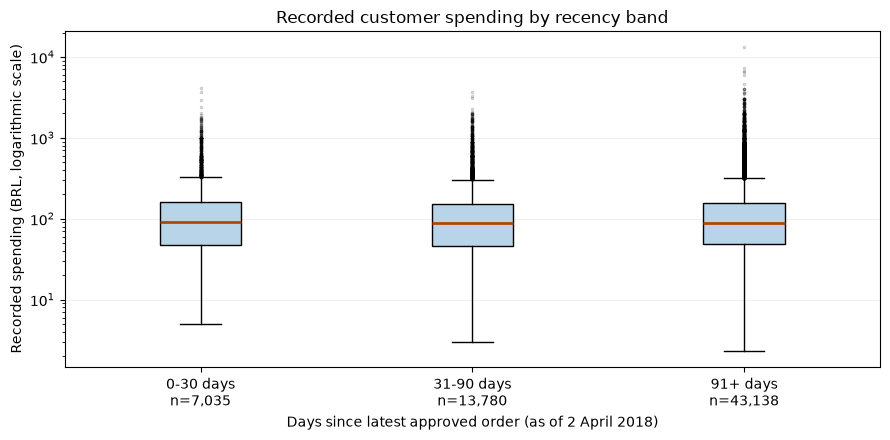

In [11]:
recency_summary = customer_groups.groupby("recency_band", observed=False).agg(
    customers=("order_frequency", "size"),
    plotted_customers=("observed_spend", "count"),
    missing_spend_customers=("missing_spend", "sum"),
    incomplete_spend_customers=("incomplete_spend", "sum"),
    median_spend_brl=("observed_spend", "median"),
)
display(recency_summary.round(2))

bands = list(customer_groups["recency_band"].cat.categories)
spending_by_band = [
    customer_groups.loc[customer_groups["recency_band"] == band, "observed_spend"]
    .dropna().to_numpy(dtype=float)
    for band in bands
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(
    spending_by_band,
    tick_labels=[f"{band}\nn={len(values):,}" for band, values in zip(bands, spending_by_band)],
    patch_artist=True,
    boxprops={"facecolor": "#b8d4e8"},
    medianprops={"color": "#b34700", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "alpha": 0.2},
)
ax.set_yscale("log")
ax.set(title="Recorded customer spending by recency band",
       xlabel="Days since latest approved order (as of 2 April 2018)",
       ylabel="Recorded spending (BRL, logarithmic scale)")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_directory / "03_spending_by_recency.png", dpi=150, bbox_inches="tight")
plt.show()


**What we see:** 97.00% of customers have one recorded order; only 149 customers have 3+ orders, so that group needs cautious interpretation. Median spending rises from BRL 85.90 to 174.40 and 280.29 across the order groups, partly reflecting the way spending accumulates across orders. The recency bands have similar spending medians (BRL 89.90, 89.00, and 89.00) and visibly overlapping distributions. Recency bands alone do not clearly separate customers by recorded spending.

**Supporting correlation check:** the existing Spearman table and recency/spending plot below help identify overlapping features. Correlation does not establish causation. The scatter plot uses a reproducible sample and excludes only missing spending.

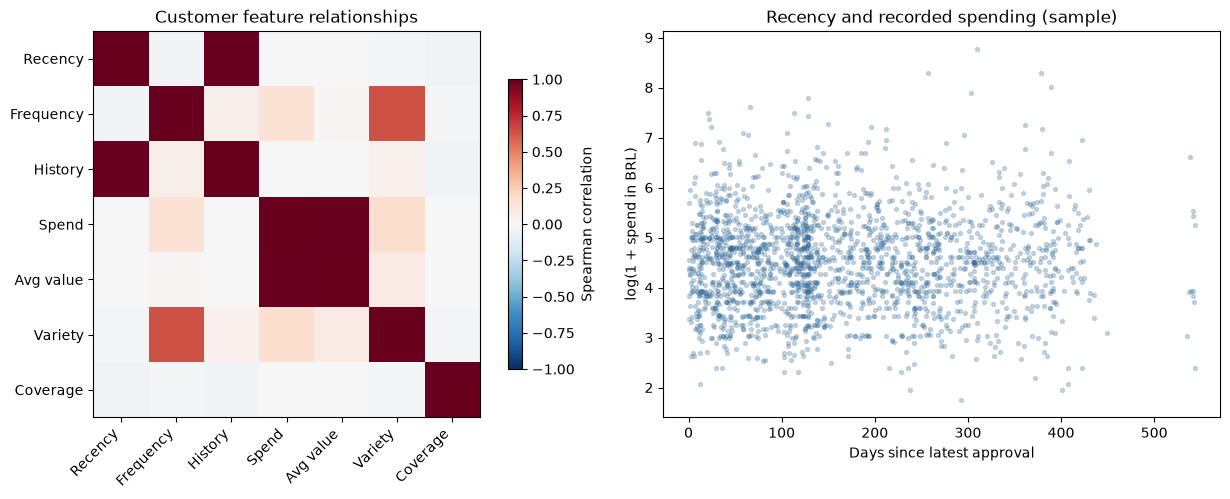

,recency_days,order_frequency,history_days,observed_spend,avg_order_value,product_variety,spend_coverage
recency_days,1.00,-0.02,0.99,-0.01,-0.00,-0.01,-0.03
order_frequency,-0.02,1.00,0.06,0.14,0.01,0.64,-0.01
history_days,0.99,0.06,1.00,0.01,-0.00,0.04,-0.04
observed_spend,-0.01,0.14,0.01,1.00,0.99,0.17,-0.00
avg_order_value,-0.00,0.01,-0.00,0.99,1.00,0.08,-0.00
product_variety,-0.01,0.64,0.04,0.17,0.08,1.00,-0.01
spend_coverage,-0.03,-0.01,-0.04,-0.00,-0.00,-0.01,1.00


In [12]:
numeric_features = [
    "recency_days", "order_frequency", "history_days", "observed_spend",
    "avg_order_value", "product_variety", "spend_coverage",
]
correlations = customer_profiles[numeric_features].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
heatmap = axes[0].imshow(correlations, vmin=-1, vmax=1, cmap="RdBu_r")
short_names = ["Recency", "Frequency", "History", "Spend", "Avg value", "Variety", "Coverage"]
axes[0].set_xticks(range(7), short_names, rotation=45, ha="right")
axes[0].set_yticks(range(7), short_names)
axes[0].set_title("Customer feature relationships")
fig.colorbar(heatmap, ax=axes[0], label="Spearman correlation", shrink=0.75)
plot_customers = customer_profiles.dropna(subset=["observed_spend"]).sample(
    n=min(2000, customer_profiles["observed_spend"].notna().sum()), random_state=42
)
axes[1].scatter(plot_customers["recency_days"], np.log1p(plot_customers["observed_spend"]),
                s=8, alpha=0.25, color="#306998")
axes[1].set(title="Recency and recorded spending (sample)",
            xlabel="Days since latest approval", ylabel="log(1 + spend in BRL)")
fig.tight_layout()
fig.savefig(figure_directory / "03_customer_features.png", dpi=150, bbox_inches="tight")
plt.show()
display(correlations.round(2))

## 3.3 Select a simple behavioral feature set

Start with recency, frequency, spending, product variety, average order value, and history length, in that priority order. A **correlation filter** drops a later feature when its absolute Spearman correlation with an already retained feature exceeds 0.90. This is feature selection without repeat-purchase labels. The threshold is a transparent initial choice, not an optimized value.

Exclude coverage indicators from clustering so missing records do not define the segments. Keep them in the profile table for later coverage checks. Retain ordinary purchase frequency: dropping A does not make historical frequency irrelevant to B. Reassess this feature set using cluster stability and business profiles in Step 5.

In [13]:
candidate_features = [
    "recency_days", "order_frequency", "observed_spend",
    "product_variety", "avg_order_value", "history_days",
]
feature_correlations = customer_profiles[candidate_features].corr(method="spearman").abs()
selected_features = []
selection_rows = []
for feature in candidate_features:
    overlaps = [kept for kept in selected_features if feature_correlations.loc[feature, kept] > 0.90]
    if not overlaps:
        selected_features.append(feature)
    selection_rows.append({"feature": feature, "kept": not overlaps,
                           "reason": "Overlaps with " + ", ".join(overlaps) if overlaps else "Retained"})
feature_selection = pd.DataFrame(selection_rows)
display(feature_selection)


,feature,kept,reason
0,recency_days,True,Retained
1,order_frequency,True,Retained
2,observed_spend,True,Retained
3,product_variety,True,Retained
4,avg_order_value,False,Overlaps with observed_spend
5,history_days,False,Overlaps with recency_days


## 3.4 Fill missing values and scale

Fill unknown numeric values with the development-profile median, reduce skew with `log1p`, then standardize the selected features. This keeps BRL amounts from dominating day/count measurements. Imputed spending remains an estimate; later segment reports should disclose missing-data coverage.

No categorical encoding is needed for these numeric behavioral inputs. Recency bands are descriptive labels only. Fit this preparation on the development snapshot; future snapshots must use the fitted transformation. Refit within training samples when evaluating stability or predictive use.

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

preparation = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("reduce_skew", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])
X_customers = preparation.fit_transform(customer_profiles[selected_features])
assert np.isfinite(X_customers).all()
print(f"Prepared {X_customers.shape[0]:,} customers and {X_customers.shape[1]} behavioral features.")
display(pd.DataFrame(X_customers[:5], columns=selected_features).round(2))


Prepared 64,494 customers and 4 behavioral features.


,recency_days,order_frequency,observed_spend,product_variety
0,1.15,-0.17,-0.25,-0.23
1,0.36,-0.17,-1.29,-0.23
2,0.16,-0.17,0.78,-0.23
3,-1.23,-0.17,1.59,3.44
4,1.16,-0.17,0.47,-0.23


## 3.5 Reduce dimensions with PCA

Fit PCA on the prepared development profiles, retaining at least 95% of input variance. Show the retained components, their main feature weights, and a two-component view. PCA summarizes the inputs; it does not establish good clusters or predict repeat purchases. Step 5 will compare clustering with selected features versus PCA using a common evaluation space and stability checks. Model-based importance and explainability will belong to forecasting later.

PCA retains 4 of 4 features; variance retained: 100.0%


,recency_days,order_frequency,observed_spend,product_variety
PC1,-0.028,0.674,0.289,0.679
PC2,0.997,-0.007,0.075,0.016
PC3,-0.070,-0.222,0.954,-0.189
PC4,-0.015,-0.704,-0.025,0.710


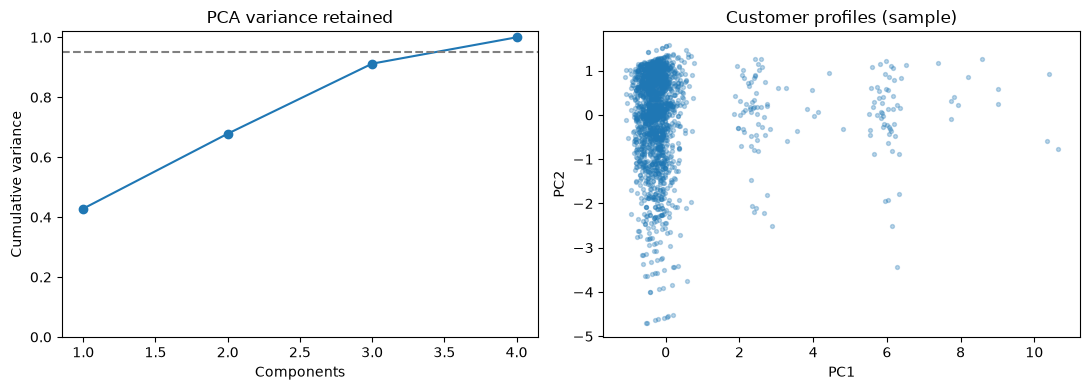

The two plotted components explain 67.8% of input variance; visible shapes are not validated segments.


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, svd_solver="full")
X_customers_pca = pca.fit_transform(X_customers)
variance = pca.explained_variance_ratio_.cumsum()
print(f"PCA retains {pca.n_components_} of {len(selected_features)} features; variance retained: {variance[-1]:.1%}")
display(pd.DataFrame(pca.components_, columns=selected_features,
                     index=[f"PC{i+1}" for i in range(pca.n_components_)]).round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, len(variance)+1), variance, marker="o")
axes[0].axhline(0.95, color="gray", linestyle="--")
axes[0].set(title="PCA variance retained", xlabel="Components", ylabel="Cumulative variance", ylim=(0, 1.02))
sample_rows = np.random.default_rng(42).choice(len(X_customers_pca), min(2000, len(X_customers_pca)), replace=False)
axes[1].scatter(X_customers_pca[sample_rows, 0], X_customers_pca[sample_rows, 1], s=8, alpha=0.3)
axes[1].set(title="Customer profiles (sample)", xlabel="PC1", ylabel="PC2")
fig.tight_layout()
fig.savefig(figure_directory / "03_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"The two plotted components explain {variance[1]:.1%} of input variance; visible shapes are not validated segments.")


**PCA finding:** the 95% rule retains all four selected features, so it provides no further compression here. The two-component visualization retains 67.8% of variance and loses the rest. Keep the four interpretable selected features as the starting point for clustering; test a reduced PCA representation later rather than assuming it improves segmentation.

## 3.6 Build weekly product features for C

Choose five relatively active products using only **2 January to 2 July 2017**: require at least eight weeks with recorded sales, then rank by item count. This small example supports readable forecasting experiments; findings will apply to these selected products, not the whole catalog.

Create every Monday-start week for each product. A zero means no recorded approved-order item rows that week; it does not prove the product was available or had no underlying demand.

| Field | Meaning / type / unit |
| --- | --- |
| product_id, week_start | Product and forecast-origin keys; string and Monday date |
| item_count | Observed item-row count in the origin week; integer >= 0; **outcome, not predictor** |
| lag_1, lag_2, lag_3, lag_4 | Counts 1, 2, 3, or 4 weeks before the origin; integers >= 0 |
| mean_last_4 | Mean count across the four prior weeks; number >= 0 |
| target_week_1 ... target_week_4 | Counts in the origin week and following three weeks; integers >= 0 |

At each origin we only know prior weeks. Shifting before rolling prevents this week's sales entering its own predictors. Remove rows without enough history or four fully observed target weeks. Product IDs remain identifiers; the five lag/mean columns are the forecasting inputs.

In [16]:
product_items = development_df.loc[development_df["order_approved_at"] >= sales_start].copy()
product_items["week_start"] = product_items["order_approved_at"].dt.to_period("W-SUN").dt.start_time
selection_end = pd.Timestamp("2017-07-03")
early_products = product_items.loc[product_items["week_start"] < selection_end].groupby("product_id").agg(
    item_rows=("order_id", "size"), active_weeks=("week_start", "nunique"),
)
eligible_products = early_products.loc[early_products["active_weeks"] >= 8].reset_index()
chosen_products = eligible_products.sort_values(
    ["item_rows", "product_id"], ascending=[False, True]
).head(5)
display(chosen_products)

weeks = pd.date_range(sales_start, development_end, freq="W-MON", inclusive="left")
grid = pd.MultiIndex.from_product([chosen_products["product_id"], weeks], names=["product_id", "week_start"])
weekly_products = (
    product_items.groupby(["product_id", "week_start"]).size()
    .reindex(grid, fill_value=0).rename("item_count").reset_index()
    .sort_values(["product_id", "week_start"])
)
grouped_counts = weekly_products.groupby("product_id")["item_count"]
for lag in [1, 2, 3, 4]:
    weekly_products[f"lag_{lag}"] = grouped_counts.shift(lag)
weekly_products["mean_last_4"] = grouped_counts.transform(lambda counts: counts.shift(1).rolling(4).mean())
for horizon in range(1, 5):
    weekly_products[f"target_week_{horizon}"] = grouped_counts.shift(-(horizon - 1))

forecast_features = ["lag_1", "lag_2", "lag_3", "lag_4", "mean_last_4"]
forecast_targets = [f"target_week_{h}" for h in range(1, 5)]
forecast_table = weekly_products.loc[weekly_products["week_start"] >= selection_end].dropna(
    subset=forecast_features + forecast_targets
).copy()
assert not forecast_table.duplicated(["product_id", "week_start"]).any()
assert (forecast_table["week_start"] + pd.Timedelta(weeks=4) <= development_end).all()
assert (forecast_table["target_week_1"] == forecast_table["item_count"]).all()
# Independently check one example against the underlying transaction dates.
example = forecast_table.iloc[0]
prior_items = product_items.loc[
    (product_items["product_id"] == example["product_id"])
    & (product_items["week_start"] < example["week_start"])
    & (product_items["week_start"] >= example["week_start"] - pd.Timedelta(weeks=4))
]
assert example["mean_last_4"] == len(prior_items) / 4
assert example["lag_1"] == (prior_items["week_start"] == example["week_start"] - pd.Timedelta(weeks=1)).sum()
print(f"Forecast table: {len(forecast_table):,} rows across {len(chosen_products)} products.")
display(forecast_table.head())

,product_id,item_rows,active_weeks
85,99a4788cb24856965c36a24e339b6058,169,18
44,42a2c92a0979a949ca4ea89ec5c7b934,87,9
16,154e7e31ebfa092203795c972e5804a6,71,18
74,7e0dc102074f8285580c9777f79c90cf,71,13
111,c6dd917a0be2a704582055949915ab32,71,19


Forecast table: 180 rows across 5 products.


,product_id,week_start,item_count,lag_1,lag_2,lag_3,lag_4,mean_last_4,target_week_1,target_week_2,target_week_3,target_week_4
156,154e7e31ebfa092203795c972e5804a6,2017-07-03,5,2.0,8.0,7.0,3.0,5.00,5,4.0,11.0,8.0
157,154e7e31ebfa092203795c972e5804a6,2017-07-10,4,5.0,2.0,8.0,7.0,5.50,4,11.0,8.0,5.0
158,154e7e31ebfa092203795c972e5804a6,2017-07-17,11,4.0,5.0,2.0,8.0,4.75,11,8.0,5.0,4.0
159,154e7e31ebfa092203795c972e5804a6,2017-07-24,8,11.0,4.0,5.0,2.0,5.50,8,5.0,4.0,11.0
160,154e7e31ebfa092203795c972e5804a6,2017-07-31,5,8.0,11.0,4.0,5.0,7.00,5,4.0,11.0,2.0


**Visual example: what is known when we make a forecast?**

Take the first row of `forecast_table`. Blue bars show the four completed weeks before its forecast date. Orange bars show the four future weekly results we want to predict. These orange values are actual historical outcomes, **not model predictions**, and must not enter the inputs.

The dashed line marks when the forecast would be made. The dotted horizontal line is `mean_last_4`, calculated only from the blue bars. The four blue bars provide `lag_4`, `lag_3`, `lag_2`, and `lag_1`; all four contribute to the average.

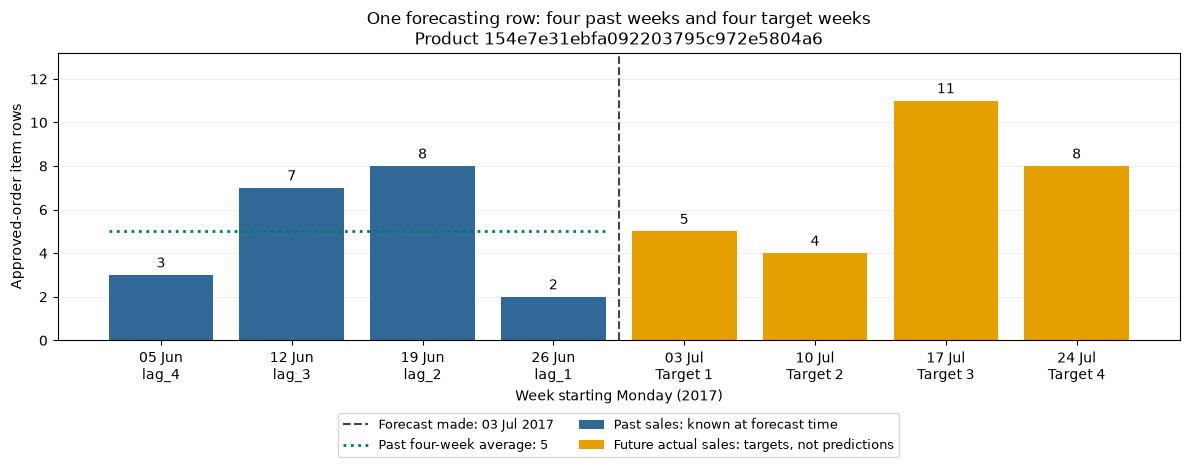

In [17]:
# Use the same example as the first displayed forecasting row.
forecast_example = forecast_table.iloc[0]
forecast_date = forecast_example["week_start"]
example_weeks = pd.date_range(
    forecast_date - pd.Timedelta(weeks=4), periods=8, freq="W-MON"
)
example_sales = (
    weekly_products.loc[weekly_products["product_id"] == forecast_example["product_id"]]
    .set_index("week_start")["item_count"].reindex(example_weeks)
)

fig, ax = plt.subplots(figsize=(12, 5))
past_bars = ax.bar(range(4), example_sales.iloc[:4], color="#306998", label="Past sales: known at forecast time")
future_bars = ax.bar(range(4, 8), example_sales.iloc[4:], color="#e69f00", label="Future actual sales: targets, not predictions")
ax.bar_label(past_bars, padding=3, fmt="%.0f")
ax.bar_label(future_bars, padding=3, fmt="%.0f")
ax.axvline(3.5, color="#444444", linestyle="--", label=f"Forecast made: {forecast_date:%d %b %Y}")
ax.hlines(forecast_example["mean_last_4"], -0.4, 3.4, color="#00796b", linestyle=":",
          linewidth=2, label=f"Past four-week average: {forecast_example['mean_last_4']:g}")
week_roles = ["lag_4", "lag_3", "lag_2", "lag_1", "Target 1", "Target 2", "Target 3", "Target 4"]
ax.set_xticks(range(8), [f"{date:%d %b}\n{role}" for date, role in zip(example_weeks, week_roles)])
ax.set(
    title=f"One forecasting row: four past weeks and four target weeks\nProduct {forecast_example['product_id']}",
    xlabel="Week starting Monday (2017)", ylabel="Approved-order item rows",
    ylim=(0, example_sales.max() * 1.2),
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.23), ncol=2, fontsize=9)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_directory / "03_forecast_window.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.7 Save the prepared work

Save customer profiles without prediction labels, the selected/scaled and PCA representations, and the weekly forecasting table. Save fitted preparation and PCA with the cutoff, feature selection, product eligibility, seed, software versions, and source manifest. Reload to verify both transformations reproduce their results.

Step 4 defines evaluation for B and C. Forecast splits must account for overlapping four-week targets. Feature importance, tuned model comparisons, and clustering validation remain later work. The earlier classification experiment is retired and is not part of the active outputs.

In [18]:
import joblib
import sklearn

processed_directory = project_root / "data" / "processed"
experiment_directory = project_root / "artifacts" / "step3_bc"
processed_directory.mkdir(parents=True, exist_ok=True)
experiment_directory.mkdir(parents=True, exist_ok=True)
customer_profiles.to_csv(processed_directory / "customer_profiles.csv")
pd.DataFrame(X_customers, index=customer_profiles.index, columns=selected_features).to_csv(
    processed_directory / "customer_features_scaled.csv")
pd.DataFrame(X_customers_pca, index=customer_profiles.index,
             columns=[f"PC{i+1}" for i in range(pca.n_components_)]).to_csv(processed_directory / "customer_features_pca.csv")
forecast_table.to_csv(processed_directory / "product_week_features.csv", index=False)
feature_selection.to_csv(experiment_directory / "feature_selection.csv", index=False)
artifact_path = experiment_directory / "customer_preparation.joblib"
joblib.dump({"preparation": preparation, "pca": pca, "selected_features": selected_features}, artifact_path)
reloaded = joblib.load(artifact_path)
reloaded_features = reloaded["preparation"].transform(customer_profiles[reloaded["selected_features"]])
assert np.allclose(reloaded_features, X_customers)
assert np.allclose(reloaded["pca"].transform(reloaded_features), X_customers_pca)
configuration = {
    "scope": "B segmentation and C observed-sales forecasting; A retired",
    "profile_cutoff": str(profile_cutoff.date()), "history_rule": "approval < cutoff",
    "selected_features": selected_features, "correlation_threshold": 0.90,
    "pca_variance_target": 0.95, "random_seed": 42,
    "product_selection_end": str(selection_end.date()),
    "selected_products": chosen_products["product_id"].tolist(),
    "forecast_features": forecast_features, "forecast_targets": forecast_targets,
    "versions": {"python": sys.version.split()[0], "pandas": pd.__version__,
                 "numpy": np.__version__, "sklearn": sklearn.__version__, "joblib": joblib.__version__},
    "source_manifest": json.loads((project_root / "docs" / "DATA_MANIFEST.json").read_text(encoding="utf-8")),
}
(experiment_directory / "configuration.json").write_text(json.dumps(configuration, indent=2), encoding="utf-8")
print("Saved B/C preparation. Reloaded transformations match.")


Saved B/C preparation. Reloaded transformations match.


<a id="step-4"></a>

# Step 4: Model Implementation

We will compare **K-Means and DBSCAN for customer segmentation (B)** to identify customer groups from recency, frequency, spending, and product variety: K-Means groups similar customers around cluster centers, while DBSCAN finds dense groups and can flag unusual customers as noise. For **weekly sales forecasting (C)**, we will compare a **Decision Tree Regressor and Random Forest Regressor** using recent weekly sales to predict the next four weeks; the tree offers a readable starting model, while the forest combines trees to capture more complex patterns. These comparisons address Step 4's requirement for appropriate trained models and evaluation: assess segmentation with silhouette, stability, and interpretable profiles, and forecasting with chronological MAE against last-week and four-week-average baselines. Keep models modest given the small forecasting sample, and save fitted models, preprocessing, configurations, and metrics for reproducibility.

## 4.1 Agree on the comparison

**B: segmentation.** Use the same random sample of 6,000 development customers for every method, keeping DBSCAN memory and repeated comparisons manageable. This is a descriptive study of that sample, not a test of future customer behavior. Fit preprocessing again on that sample. Compare the four selected features with a genuinely reduced two-component PCA version; score both in the same four-feature space. The full-data EDA informed feature choice, so no unseen-customer performance is claimed.

Try K-Means with 2-6 clusters and DBSCAN with neighborhood radii 0.2/0.4/0.6 and minimum-neighbor counts 10/30. Use a fixed 1,500-customer evaluation sample. A candidate must have 2-8 clusters, assign at least 95% of customers, and have no assigned cluster smaller than 1% of assigned customers. These are initial business-coverage rules, not universal statistical thresholds. Check finalists on three 80% resamples; refit preprocessing and PCA each time. Prefer stable, interpretable groups, not just a high silhouette. A simple RFM rule is the reference.

**C: forecasting.** Pool the five products into one model with five lag/mean inputs and four outputs. Product IDs identify rows but are not predictors. Tune using four weekly forecast dates starting 2 October 2017, 6 November 2017, and 1 January 2018. At each start, fit only rows whose four-week outcomes have finished. Select the ML candidate using mean validation MAE, keep the best baseline as a benchmark only, then compare the fixed methods on weekly forecast dates from **2 April to 25 June 2018** (outcomes end 23 July). Models stay fixed during this final period; each Monday's lag inputs update using then-known sales. This tests existing products, not unseen-product generalization.

For business reporting, B shows group size, recorded-spending share, and data coverage. C reports mean absolute error, signed over/underprediction, and percentage error reduction against the validation-chosen baseline. These measure descriptive utility and forecasting error, not causal revenue or inventory savings. Adjacent four-week targets overlap; we do not treat them as independent trials.

**Split review:** weekly forecasting already keeps training outcomes before each validation/test date. Clustering uses historical profiles and refits preparation in each stability run; its scores describe the sampled customers, not unseen-customer performance. The previously viewed forecast test period remains a historical backtest.


In [19]:
# Bound notebook compute and avoid Windows physical-core discovery warnings.
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
import threadpoolctl

from time import perf_counter
from sklearn.base import clone
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from threadpoolctl import threadpool_limits

step4_started = perf_counter()
SEED = 42
model_directory = project_root / "models"
result_directory = project_root / "reports" / "tables"
config_directory = project_root / "configs"
for directory in [model_directory, result_directory, config_directory]:
    directory.mkdir(parents=True, exist_ok=True)

cluster_customers = customer_profiles.sample(n=min(6000, len(customer_profiles)), random_state=SEED).copy()
cluster_preparation = clone(preparation)
cluster_X = cluster_preparation.fit_transform(cluster_customers[selected_features])
cluster_pca = PCA(n_components=2, svd_solver="full").fit(cluster_X)
cluster_spaces = {"Selected features": cluster_X, "PCA (2)": cluster_pca.transform(cluster_X)}
score_rows = np.random.default_rng(SEED).choice(len(cluster_X), min(1500, len(cluster_X)), replace=False)
print(f"Clustering sample: {len(cluster_X):,} of {len(customer_profiles):,} customers.")
print(f"Two PCA components retain {cluster_pca.explained_variance_ratio_.sum():.1%} of sample variance.")

Clustering sample: 6,000 of 64,494 customers.
Two PCA components retain 67.8% of sample variance.


## 4.2 Fit and compare customer groups

Silhouette measures separation (higher is better), but noise points from DBSCAN are excluded from its score. Always read it alongside coverage and cluster sizes. A one-cluster result has no valid silhouette. The RFM reference splits customers by recent/not recent (90 days), one/multiple orders, and below/above the sample median recorded spend; missing spend uses the sample median only for assigning the rule.

We first tune each model/representation combination. Finalists are then compared on exactly the same customers assigned by all finalists. PCA scores are computed using distances in the selected-feature space, not its two-dimensional projection. See the [scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html) for model behavior and metric limitations.

In [20]:
def cluster_metrics(labels):
    assigned = labels >= 0
    sizes = pd.Series(labels[assigned]).value_counts()
    selected_rows = score_rows[assigned[score_rows]]
    sampled_labels = labels[selected_rows]
    valid = 2 <= len(np.unique(sampled_labels)) < len(sampled_labels)
    score = silhouette_score(cluster_X[selected_rows], sampled_labels) if valid else np.nan
    return {"silhouette": score, "clusters": len(sizes), "coverage": assigned.mean(),
            "smallest_cluster_share": sizes.min() / sizes.sum() if len(sizes) else 0}

rfm_spend_median = float(cluster_customers["observed_spend"].median())
rfm_labels = (
    4 * (cluster_customers["recency_days"] <= 90).astype(int)
    + 2 * (cluster_customers["order_frequency"] > 1).astype(int)
    + (cluster_customers["observed_spend"].fillna(rfm_spend_median) >= rfm_spend_median).astype(int)
).to_numpy()
cluster_trials, cluster_fits = [], {}
with threadpool_limits(limits=2):
    for representation, inputs in cluster_spaces.items():
        candidates = [("K-Means", {"n_clusters": k}) for k in range(2, 7)]
        candidates += [("DBSCAN", params) for params in ParameterGrid({"eps": [0.2, 0.4, 0.6], "min_samples": [10, 30]})]
        for family, params in candidates:
            started = perf_counter()
            model = (KMeans(**params, n_init=10, random_state=SEED) if family == "K-Means"
                     else DBSCAN(**params, n_jobs=1))
            labels = model.fit_predict(inputs)
            trial_id = f"cluster_{len(cluster_trials):02d}"
            metrics = cluster_metrics(labels)
            eligible = (2 <= metrics["clusters"] <= 8 and metrics["coverage"] >= 0.95
                        and metrics["smallest_cluster_share"] >= 0.01 and metrics["silhouette"] > 0)
            cluster_trials.append({"trial": trial_id, "family": family, "representation": representation,
                                   "parameters": json.dumps(params), **metrics, "eligible": eligible,
                                   "seconds": perf_counter() - started,
                                   "inertia": model.inertia_ if family == "K-Means" else np.nan})
            cluster_fits[trial_id] = {"model": model, "labels": labels, "representation": representation}
cluster_comparison = pd.DataFrame(cluster_trials)
display(cluster_comparison.drop(columns=["seconds", "inertia"]).round(3))
with threadpool_limits(limits=2):
    display(pd.DataFrame([{"model": "RFM rule", **cluster_metrics(rfm_labels)}]).round(3))

,trial,family,representation,parameters,silhouette,clusters,coverage,smallest_cluster_share,eligible
0,cluster_00,K-Means,Selected features,"{""n_clusters"": 2}",0.743,2,1.000,0.033,True
1,cluster_01,K-Means,Selected features,"{""n_clusters"": 3}",0.360,3,1.000,0.033,True
2,cluster_02,K-Means,Selected features,"{""n_clusters"": 4}",0.343,4,1.000,0.033,True
3,cluster_03,K-Means,Selected features,"{""n_clusters"": 5}",0.373,5,1.000,0.028,True
4,cluster_04,K-Means,Selected features,"{""n_clusters"": 6}",0.337,6,1.000,0.028,True
5,cluster_05,DBSCAN,Selected features,"{""eps"": 0.2, ""min_samples"": 10}",0.243,6,0.901,0.001,False
6,cluster_06,DBSCAN,Selected features,"{""eps"": 0.2, ""min_samples"": 30}",NaN,1,0.796,1.000,False
7,cluster_07,DBSCAN,Selected features,"{""eps"": 0.4, ""min_samples"": 10}",0.554,6,0.965,0.002,False
8,cluster_08,DBSCAN,Selected features,"{""eps"": 0.4, ""min_samples"": 30}",NaN,1,0.917,1.000,False
9,cluster_09,DBSCAN,Selected features,"{""eps"": 0.6, ""min_samples"": 10}",0.560,4,0.980,0.003,False


,model,silhouette,clusters,coverage,smallest_cluster_share
0,RFM rule,0.295,8,1.0,0.001


## 4.3 Check stability before choosing a segmentation

For the best eligible trial from each family/representation, refit on three different 80% subsets. **Adjusted Rand index (ARI)** measures whether the shared customers stay grouped similarly, regardless of cluster-number labels. We report ARI both with noise as a label and among customers assigned in both runs, plus shared assignment coverage. A mean assigned-customer ARI of at least 0.75 is our initial stability screen.

Choose the stable finalist with the highest silhouette on the common assigned sample. If none passes, report a provisional example rather than claiming reliable segments. Repeated fits measure resampling robustness within this historical sample; they do not establish future stability.

In [21]:
eligible_trials = cluster_comparison.loc[cluster_comparison["eligible"]]
finalists = (eligible_trials.sort_values("silhouette", ascending=False)
             .groupby(["family", "representation"], sort=False).head(1).copy())
if finalists.empty:
    raise ValueError("No clustering trial passes the declared coverage/size rules; inspect before proceeding.")
stability_rows = []
with threadpool_limits(limits=2):
    for _, trial in finalists.iterrows():
        fitted = cluster_fits[trial["trial"]]
        for seed in [7, 21, 84]:
            rows = np.random.default_rng(seed).choice(len(cluster_X), int(0.8 * len(cluster_X)), replace=False)
            resample_preparation = clone(cluster_preparation)
            inputs = resample_preparation.fit_transform(cluster_customers.iloc[rows][selected_features])
            if trial["representation"] == "PCA (2)":
                inputs = PCA(n_components=2, svd_solver="full").fit_transform(inputs)
            model = clone(fitted["model"])
            if trial["family"] == "K-Means":
                model.set_params(random_state=seed)
            new_labels = model.fit_predict(inputs)
            old_labels = fitted["labels"][rows]
            shared = (old_labels >= 0) & (new_labels >= 0)
            valid = shared.sum() > 1 and len(np.unique(old_labels[shared])) > 1 and len(np.unique(new_labels[shared])) > 1
            stability_rows.append({"trial": trial["trial"], "seed": seed,
                "ari_with_noise": adjusted_rand_score(old_labels, new_labels),
                "ari_assigned": adjusted_rand_score(old_labels[shared], new_labels[shared]) if valid else np.nan,
                "shared_assigned_share": shared.mean()})
stability_results = pd.DataFrame(stability_rows)
finalists = finalists.merge(stability_results.groupby("trial").agg(
    stability_mean=("ari_assigned", "mean"), stability_min=("ari_assigned", "min"),
    stability_runs=("ari_assigned", "count"), shared_coverage=("shared_assigned_share", "mean"),
), on="trial", validate="one_to_one")
common_rows = score_rows.copy()
for trial_id in finalists["trial"]:
    common_rows = common_rows[cluster_fits[trial_id]["labels"][common_rows] >= 0]
def common_silhouette(labels):
    labels = labels[common_rows]
    return silhouette_score(cluster_X[common_rows], labels) if 2 <= len(np.unique(labels)) < len(labels) else np.nan
with threadpool_limits(limits=2):
    finalists["common_silhouette"] = [common_silhouette(cluster_fits[t]["labels"]) for t in finalists["trial"]]
    rfm_common_silhouette = common_silhouette(rfm_labels)
stable_finalists = finalists.loc[(finalists["stability_mean"] >= 0.75) & (finalists["stability_runs"] == 3)
                                & (finalists["shared_coverage"] >= 0.95)]
segmentation_stable = not stable_finalists.empty
selection_pool = stable_finalists if segmentation_stable else finalists
chosen_cluster_row = selection_pool.sort_values("common_silhouette", ascending=False).iloc[0]
chosen_cluster_id = chosen_cluster_row["trial"]
chosen_cluster = cluster_fits[chosen_cluster_id]
display(finalists[["trial", "family", "representation", "clusters", "coverage", "common_silhouette",
                   "stability_mean", "stability_min", "shared_coverage"]].round(3))
print(f"Common evaluation customers: {len(common_rows):,}; RFM reference silhouette: {rfm_common_silhouette:.3f}")
print(f"Selected sample segmentation: {chosen_cluster_id}; stability screen passed: {segmentation_stable}")

,trial,family,representation,clusters,coverage,common_silhouette,stability_mean,stability_min,shared_coverage
0,cluster_00,K-Means,Selected features,2,1.000,0.741,1.0,1.0,1.000
1,cluster_11,K-Means,PCA (2),2,1.000,0.741,1.0,1.0,1.000
2,cluster_19,DBSCAN,PCA (2),3,0.971,0.602,1.0,1.0,0.962


Common evaluation customers: 1,453; RFM reference silhouette: 0.320
Selected sample segmentation: cluster_00; stability screen passed: True


**Read the clustering performance visually.** Left: clearer group separation gives a higher silhouette, measured on the same common customers and feature space. Middle: coverage shows how many of the full 6,000-customer sample receive a group. Right: stability shows agreement across three resamples, both among assigned customers and with noise included. Higher is better, but stable groups may still be too broad to support useful business actions. The RFM reference has no resampling test here.

The silhouette bars use only the common assigned scoring sample; they do not describe customers excluded as DBSCAN noise. The coverage panel makes that exclusion visible. Only eligible finalists are plotted; all trials remain in the earlier table.

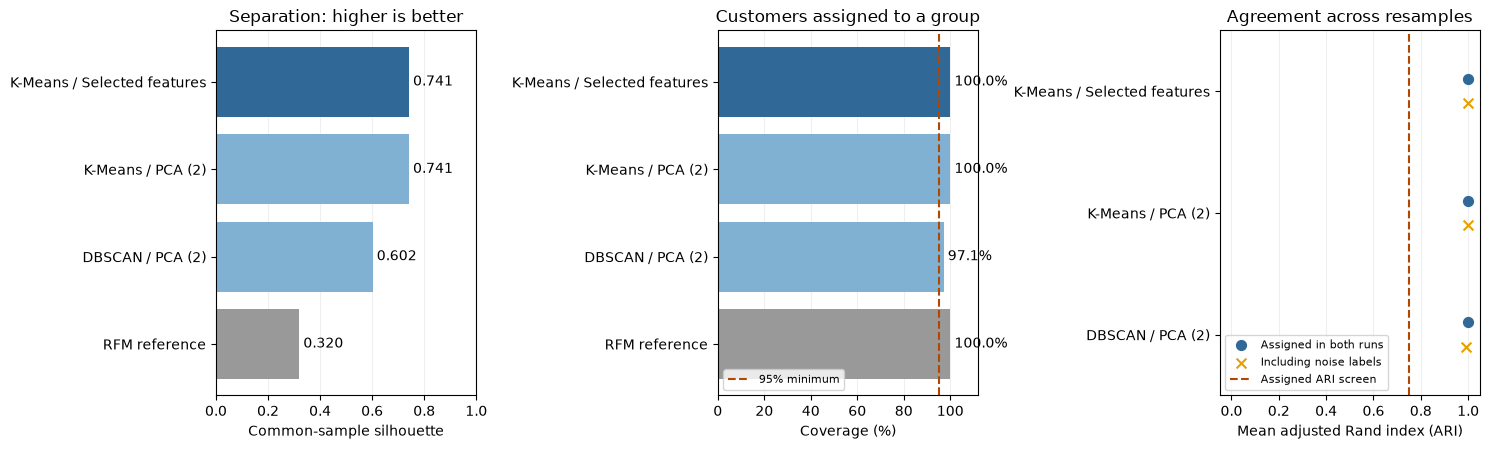

In [22]:
cluster_plot = finalists.copy()
cluster_plot["name"] = cluster_plot["family"] + " / " + cluster_plot["representation"]
noise_stability = stability_results.groupby("trial")["ari_with_noise"].mean()
cluster_plot["ari_with_noise"] = cluster_plot["trial"].map(noise_stability)
names = cluster_plot["name"].tolist()
colors = ["#306998" if trial == chosen_cluster_id else "#80b1d3" for trial in cluster_plot["trial"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

separation = cluster_plot["common_silhouette"].tolist() + [rfm_common_silhouette]
bars = axes[0].barh(names + ["RFM reference"], separation, color=colors + ["#999999"])
axes[0].bar_label(bars, fmt="%.3f", padding=3)
axes[0].set(title="Separation: higher is better", xlabel="Common-sample silhouette", xlim=(0, 1))
axes[0].invert_yaxis()

bars = axes[1].barh(names + ["RFM reference"], cluster_plot["coverage"].mul(100).tolist() + [100],
                    color=colors + ["#999999"])
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].axvline(95, linestyle="--", color="#b34700", label="95% minimum")
axes[1].set(title="Customers assigned to a group", xlabel="Coverage (%)", xlim=(0, 112))
axes[1].invert_yaxis()
axes[1].legend(fontsize=8, loc="lower left")

positions = np.arange(len(cluster_plot))
axes[2].scatter(cluster_plot["stability_mean"], positions-0.1, label="Assigned in both runs", color="#306998", s=50)
axes[2].scatter(cluster_plot["ari_with_noise"], positions+0.1, label="Including noise labels", color="#e69f00", marker="x", s=50)
axes[2].axvline(0.75, linestyle="--", color="#b34700", label="Assigned ARI screen")
axes[2].set_yticks(positions, names)
axes[2].set(title="Agreement across resamples", xlabel="Mean adjusted Rand index (ARI)", xlim=(-0.05, 1.05))
axes[2].set_ylim(len(cluster_plot)-0.5, -0.5)
axes[2].legend(fontsize=8, loc="lower left")
for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(figure_directory / "04_cluster_performance.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.4 What customer segments did we find?

**Yes: the selected model separates the 6,000 sampled customers into two broad purchasing-behavior groups.** The useful result is what distinguishes them, not their cluster numbers. These are descriptive groups in the development sample, not proof that the entire marketplace contains exactly two customer types.

We call them **Single-order customers** and **Repeat or broader-basket customers**, based on the observed profiles below. The second name matters: some customers in that group placed only one order but bought a wider range of products. Spending refers to available approved-order item prices, not profit, completed deliveries, or verified cash receipts. Unknown spending is excluded from spending summaries and its coverage remains visible.

,customers,recency_days,orders,spend_brl,product_variety,recorded_spend,missing_spend_customers,incomplete_spend_customers,customer_share_pct,recorded_spend_share_pct
segment,,,,,,,,,,
0,5800,142.0,1.0,84.99,1.0,771279.41,41,41,96.67,93.84
1,200,127.0,2.0,176.95,2.0,50628.47,0,4,3.33,6.16


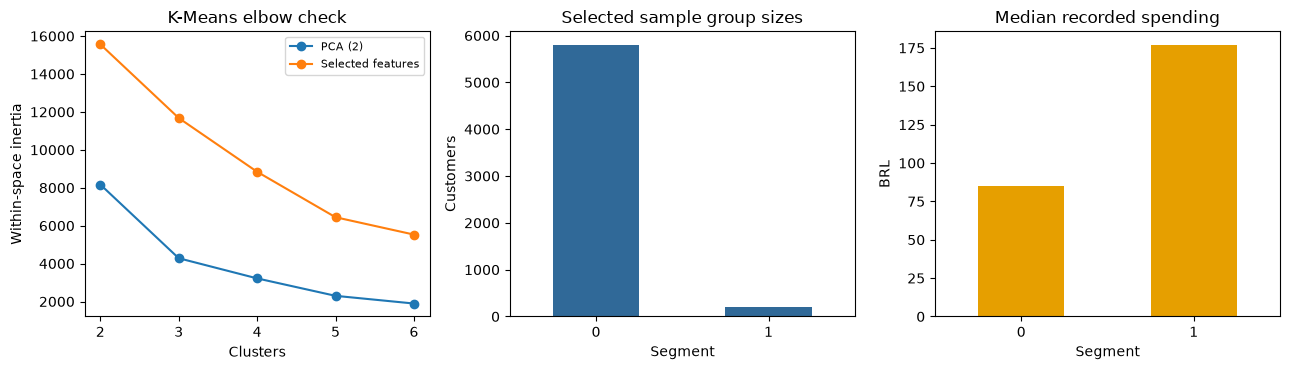

Inertia is only compared within each representation; silhouette comparisons use a common space.


In [23]:
cluster_profiles = cluster_customers.assign(segment=chosen_cluster["labels"])
cluster_profiles["missing_spend"] = cluster_profiles["observed_spend"].isna()
cluster_profiles["incomplete_spend"] = cluster_profiles["spend_coverage"] < 1
segment_summary = cluster_profiles.groupby("segment").agg(
    customers=("order_frequency", "size"), recency_days=("recency_days", "median"),
    orders=("order_frequency", "median"), spend_brl=("observed_spend", "median"),
    product_variety=("product_variety", "median"), recorded_spend=("observed_spend", "sum"),
    missing_spend_customers=("missing_spend", "sum"), incomplete_spend_customers=("incomplete_spend", "sum"),
)
segment_summary["customer_share_pct"] = 100 * segment_summary["customers"] / len(cluster_profiles)
segment_summary["recorded_spend_share_pct"] = 100 * segment_summary["recorded_spend"] / segment_summary["recorded_spend"].sum()
display(segment_summary.round(2))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for representation, rows in cluster_comparison.loc[cluster_comparison["family"] == "K-Means"].groupby("representation"):
    axes[0].plot(rows["clusters"], rows["inertia"], marker="o", label=representation)
axes[0].set(title="K-Means elbow check", xlabel="Clusters", ylabel="Within-space inertia")
axes[0].legend(fontsize=8)
segment_summary["customers"].plot.bar(ax=axes[1], color="#306998", rot=0)
axes[1].set(title="Selected sample group sizes", xlabel="Segment", ylabel="Customers")
segment_summary["spend_brl"].plot.bar(ax=axes[2], color="#e69f00", rot=0)
axes[2].set(title="Median recorded spending", xlabel="Segment", ylabel="BRL")
fig.tight_layout()
fig.savefig(figure_directory / "04_customer_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Inertia is only compared within each representation; silhouette comparisons use a common space.")

In [24]:
# Describe the selected groups using the original customer records.
segment_names = {0: "Single-order customers", 1: "Repeat or broader-basket customers"}
business_customers = cluster_profiles.assign(
    repeat_customer=cluster_profiles["order_frequency"] > 1,
    multiple_products=cluster_profiles["product_variety"] > 1,
    recent_customer=cluster_profiles["recency_days"] <= 90,
)
segment_business = business_customers.groupby("segment").agg(
    customers=("order_frequency", "size"),
    repeat_customer_pct=("repeat_customer", "mean"),
    multiple_products_pct=("multiple_products", "mean"),
    recent_customer_pct=("recent_customer", "mean"),
    median_days_since_order=("recency_days", "median"),
    median_recorded_spend_brl=("observed_spend", "median"),
    incomplete_spend_customers=("incomplete_spend", "sum"),
)
for column in ["repeat_customer_pct", "multiple_products_pct", "recent_customer_pct"]:
    segment_business[column] *= 100
segment_business.insert(0, "description", segment_business.index.map(segment_names))
segment_business["customer_share_pct"] = segment_summary["customer_share_pct"]
segment_business["recorded_spend_share_pct"] = segment_summary["recorded_spend_share_pct"]
display(segment_business.round(2))
segment_business.to_csv(result_directory / "04_customer_business_profiles.csv")


,description,customers,repeat_customer_pct,multiple_products_pct,recent_customer_pct,median_days_since_order,median_recorded_spend_brl,incomplete_spend_customers,customer_share_pct,recorded_spend_share_pct
segment,,,,,,,,,,
0,Single-order customers,5800,0.0,2.5,32.74,142.0,84.99,41,96.67,93.84
1,Repeat or broader-basket customers,200,89.0,90.0,38.50,127.0,176.95,4,3.33,6.16


**What this tells the business**

| Finding | Interpretation | Suggested next decision, not a proven intervention |
| --- | --- | --- |
| **Single-order group:** 5,800 customers (96.7%), all with one recorded order; median spend BRL 84.99 | This is the main customer base and accounts for **93.8% of recorded sample spending**, despite lower spending per customer. Only 32.7% ordered within the last 90 days. | Investigate the first-purchase experience and reasons for not returning before designing a small, measurable repeat-purchase initiative. Do not neglect this group simply because its individual spend is lower. |
| **Repeat or broader-basket group:** 200 customers (3.3%); **89%** have multiple orders and **90%** have multiple products; median spend BRL 176.95 | This small group shows more purchasing activity and contributes **6.2% of recorded sample spending**. It is not exclusively repeat buyers: 22 customers still have one order. | Examine the products bought together and customer needs to propose relevant bundles or follow-up offers, then test whether they add value. The current model does not establish which offer works. |
| Median time since last order is **142 versus 127 days**; only **38.5%** of the smaller group ordered within 90 days | The difference is mainly purchasing frequency/variety, not a clean active-versus-inactive split. Higher historical spend does not establish future loyalty. | Avoid naming the groups "loyal", "churned", or "VIP". Use recency within each group when investigating engagement. |

**How much business value does this segmentation add?** It gives us a clear starting description, but much of the distinction is already visible in ordinary order-count and product-variety summaries. The high silhouette and stability do not establish extra value over those simple summaries. Before operational use, verify profiles across the full customer population and another period, then measure whether a segment-specific action performs better than a simple rule. No campaign uplift, future purchases, or lifetime value has been demonstrated.

These observations apply to the **6,000-customer sample before 2 April 2018**. Purchase windows differ across customers, and 41 customers in the larger group have missing spend; four in the smaller group have incomplete item coverage. These limitations affect interpretation without invalidating the observed differences.

Note: Quite not satisfied with the test results since it was pretty obvious from the initial EDA that the dataset was dominated by one order customers rather than repeat customers. The DBSCAN and K-means agreed to this by having the highest silhoutte score on the two groupings. If allowed to further experiment on this dataset, I would look into the reasons why the customerbase only ordered once. Possible reasons are delayed orders, poor quality of product, and prices.

## 4.5 Choose a forecasting model

**Goal:** use the past four weeks of sales to predict the next four weeks.

We compare **Decision Tree** and **Random Forest** using earlier dates. Random Forest has the lower validation error, so it is our selected ML model. Simple averages remain benchmarks only.

The utility below runs the same comparisons as before. [Supporting code](../src/olist_analytics/forecasting.py) contains the tuning loops, date checks, and detailed results.

In [25]:
from src.olist_analytics.forecasting import (
    run_forecasting, plot_errors, plot_product_forecasts, plot_input_reliance, save_results,
)

forecasts = run_forecasting(
    forecast_table, consolidated_df, chosen_products,
    history_start=sales_start, features=forecast_features,
    targets=forecast_targets, raw_directory=raw,
)

# Show the best setting from each ML family.
display(forecasts.ml_ranking.drop_duplicates("family")[["family", "validation_mae"]].round(2))
print("Selected ML model: Random Forest")

,family,validation_mae
9,Random forest,2.00
1,Decision tree,2.11


Selected ML model: Random Forest


## 4.6 How accurate is it?

**Random Forest misses by about 1.02 items per weekly forecast on average.** It beats Decision Tree, but the four-week-average benchmark does better at 0.89.

Lower bars are better. Blue bars are ML models; gray bars are simple benchmarks. **Being the best ML candidate does not mean it is the best forecasting method overall.**

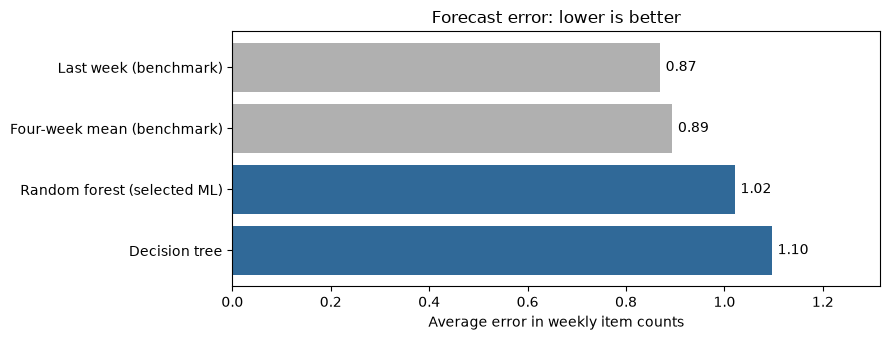

In [26]:
plot_errors(forecasts, figure_directory)

## 4.7 What does this tell the business?

**Blue is the model's forecast; black is what actually happened.** The charts show the first evaluation date for all five products. They are historical examples, not forecasts for today.

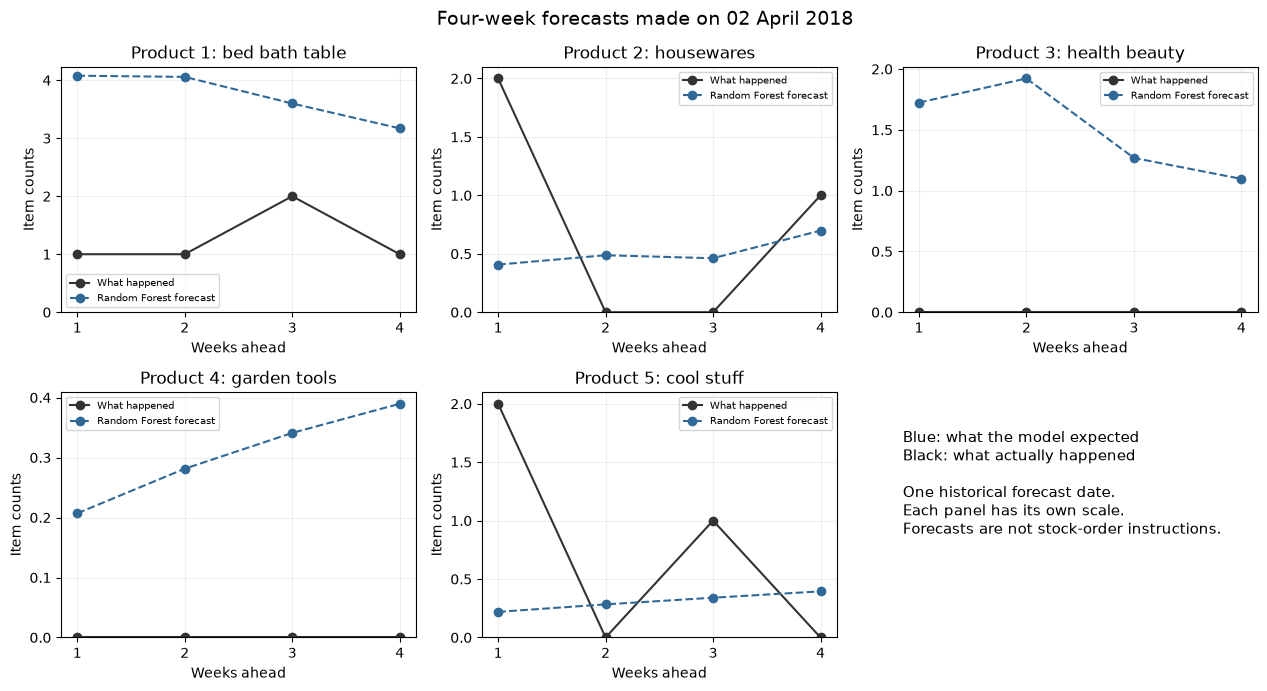

In [27]:
plot_product_forecasts(forecasts, figure_directory)

Across the full **16-week evaluation period**:

| Finding | What the business should investigate |
| --- | --- |
| Product 1 accounts for about **78% of recorded sales** among these five products. Its weekly forecasts still miss important changes. | Give this product the most planning attention and review forecasts before ordering stock. |
| Products 2, 3, and 5 sell only occasionally. The model struggles to predict the timing. | Check recent activity and availability rather than assuming steady weekly sales. |
| Product 4 has no recorded sales during the evaluation, yet the model predicts small positive amounts. | Check whether it is still available. Do not automatically replenish from these estimates. |

These are findings for **five selected products**, not their whole categories. Suggested actions still need testing; we have not demonstrated cost savings.

**What does the model rely on?** Mostly the recent four-week average and last week's sales. The next chart checks this by shuffling each input and measuring the extra error. Larger bars mean greater reliance; the lines show variation across validation periods. Related inputs make this an approximate explanation, not a cause of demand.

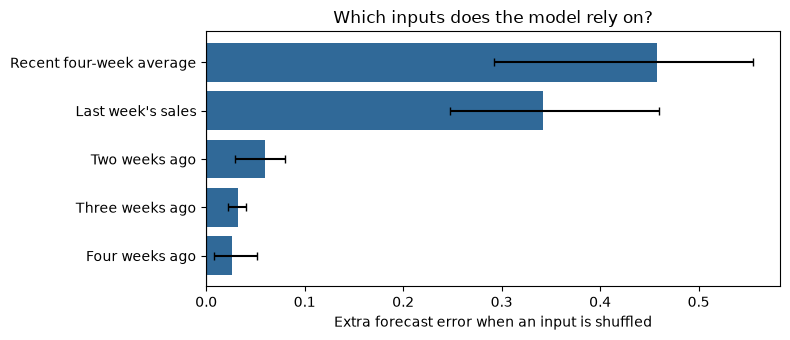

In [28]:
plot_input_reliance(forecasts, figure_directory)

**Takeaway:** Random Forest produces useful-to-inspect forecasts, but currently needs manual review and does not beat the simple average overall.

## 4.8 Save the work

Save models, settings, detailed tables, and reload checks for reproducibility. The lengthy export code is in the utility file.

**Evaluation note:** ML-only selection was requested after the earlier test results were viewed. The same validation ranking selects Random Forest; predictions and model settings are unchanged. This is not a new untouched test.

In [29]:
# Keep the clustering and forecasting results together when saving.
clustering = {
    "finalists": finalists, "fits": cluster_fits,
    "preparation": cluster_preparation, "pca": cluster_pca,
    "features": selected_features, "customers": cluster_customers,
    "selected": chosen_cluster_id, "spaces": cluster_spaces,
    "trials": cluster_comparison, "stability": stability_results,
    "summary": segment_summary, "profiles": cluster_profiles,
    "score_rows": score_rows, "common_rows": common_rows,
    "reference_silhouette": rfm_common_silhouette, "stable": segmentation_stable,
    "spend_median": rfm_spend_median, "cutoff": profile_cutoff,
    "product_selection_end": selection_end,
}
saved_results = save_results(
    forecasts, clustering, project_root, configuration,
    elapsed_seconds=perf_counter() - step4_started,
)
print("Models and results saved. Reload checks passed.")

Models and results saved. Reload checks passed.


## 4.9 Daily sales: is each product moving up or down?

Predict **items per day** with Random Forest, using only the date, month, day of month, and day of week. No previous sales or weekly averages are model inputs. Sales here mean recorded items on their order-approval date, not revenue or confirmed deliveries.

Choose the **top five products by training-period item sales**. These can differ from the earlier weekly examples. Keep zero-sales days.

| Stage | Dates | Purpose |
| --- | --- | --- |
| Train | 2 Jan?31 Dec 2017 | Select products and learn patterns |
| Validate | 1 Jan?1 Apr 2018 | Choose among four small Random Forest settings |
| Test | 2 Apr?22 Jul 2018 | Check predictions after fixing the settings |

Refit on train + validation before predicting every test day. No random date splitting or test-period refitting. This is a historical backtest: these dates have already appeared in our analysis.

In [30]:
from src.olist_analytics.daily_forecasting import run_daily_forecasting, show_daily_results

daily_forecasts = run_daily_forecasting(consolidated_df, project_root, configuration)
# Full product IDs make these five products easy to find in the source data.
display(daily_forecasts.products.rename(columns={
    "product": "Product", "product_id": "Product ID", "training_items": "Training items",
}))

,Product ID,Training items,Product
0,99a4788cb24856965c36a24e339b6058,358,Daily product 1
1,422879e10f46682990de24d770e7f83d,275,Daily product 2
2,154e7e31ebfa092203795c972e5804a6,225,Daily product 3
3,389d119b48cf3043d311335e499d9c6b,219,Daily product 4
4,53759a2ecddad2bb87a079a1f1519f73,217,Daily product 5


**Read the results:** compare the first 28 test days with the last 28. An increase above **0.1 items/day** is "Upward"; a decrease below ?0.1 is "Downward"; otherwise, "Roughly flat." This is a simple reporting rule, not a statistical significance test.

The table separates **predicted trend** from **actual trend**. Lower error is better. The average rule is a comparison using each product's last 28 pre-test days; it cannot be selected as our ML model.

,Product,Predicted items/day: start,Predicted items/day: end,Predicted trend,Actual trend,RF error,Average-rule error
0,Daily product 1,0.52,0.57,Roughly flat,Upward,0.70,0.71
1,Daily product 2,1.04,1.05,Roughly flat,Downward,1.27,1.23
2,Daily product 3,0.26,0.49,Upward,Roughly flat,0.42,0.32
3,Daily product 4,1.05,1.08,Roughly flat,Upward,0.96,0.90
4,Daily product 5,0.82,0.83,Roughly flat,Downward,0.90,0.92


Trend direction matched for 0/5 products. Average daily error: RF 0.85; average rule 0.82 items.
RF does not beat the comparison rule overall; use it cautiously for planning.


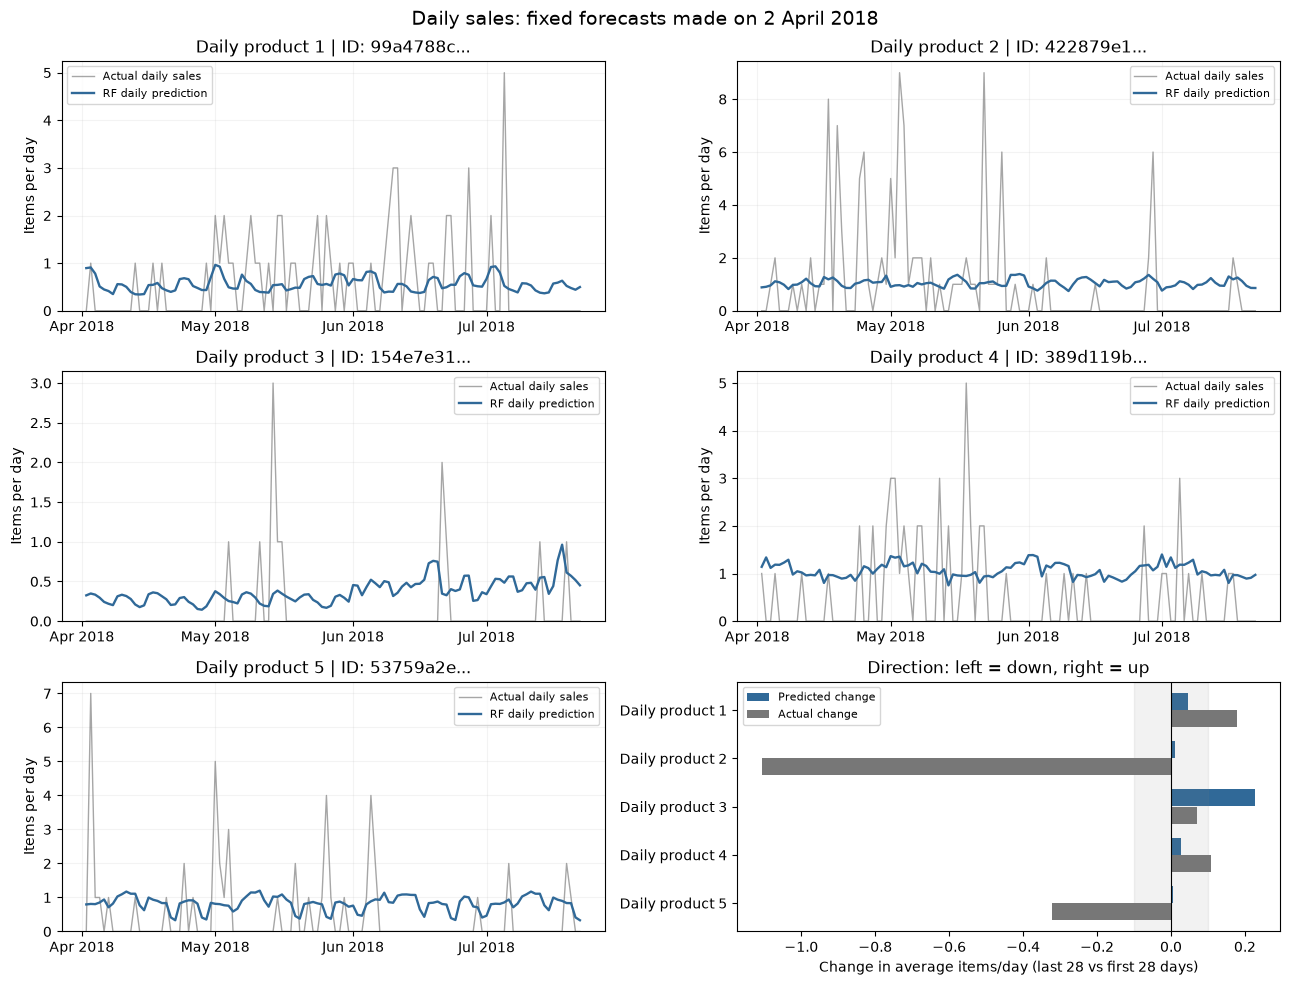

In [31]:
show_daily_results(daily_forecasts, figure_directory)

**What happened here:** daily products 2 and 5 declined, but Random Forest predicted roughly flat sales. None of the five trend labels matched; this version is not reliable enough to determine product direction on its own.

**Business use:** a rise suggests reviewing stock availability; a fall suggests investigating availability or declining activity. When predicted and actual directions disagree, the model has not captured the change reliably.

Random Forest cannot extend a rising or falling time trend indefinitely. Without recent sales inputs, it mostly reuses calendar patterns. Zero recorded sales also do not prove zero demand. These charts describe the historical test period, not today's demand.

Models, product IDs, splits, predictions, and settings are saved; reloaded models reproduce the forecasts.

<a id="step-5"></a>

# Step 5: Critical Thinking, Ethical AI & Bias Auditing

## Bias & Fairness Analysis

**Question:** what have the models learned, where do they fail, and who could be overlooked?

### 5.1 Explain the predictions

For the weekly Random Forest, **PDP** shows the average response when we change one input; **ICE** shows individual product-date responses. Dark lines are the average; pale lines show examples. We explain week 1 using development data, without retraining.

The sales lags and their average are linked. Changing one alone can create unrealistic combinations, so these plots explain model behaviour, not what causes sales. [PDP/ICE method](https://scikit-learn.org/stable/modules/partial_dependence.html)

For clustering, the original profiles in 4.4 provide the explanation: spending, frequency, recency, and product variety distinguish the groups. A segment is not a measure of a person's worth.

Last week's item sales: average prediction changes by +1.37 items from the left to right end of the chart.
Recent four-week average: average prediction changes by +4.26 items from the left to right end of the chart.


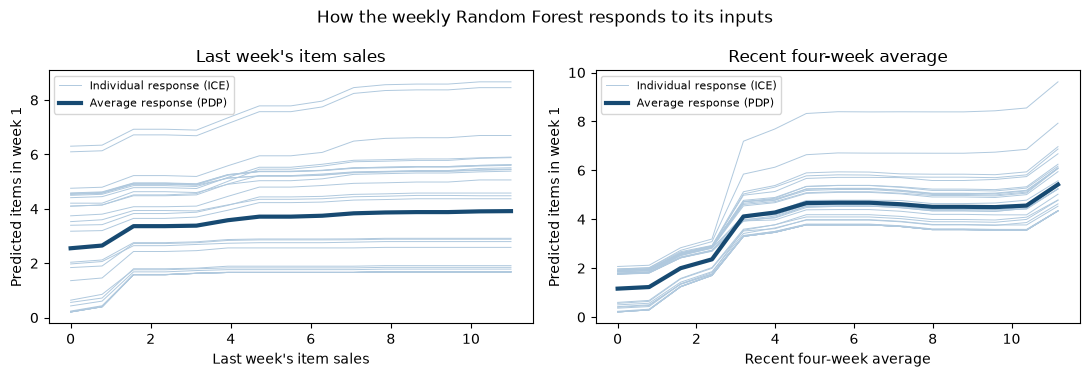

In [32]:
from src.olist_analytics.bias_audit import (
    run_bias_audit, show_model_explanation, show_geographic_audit, export_bias_report,
)

bias_audit = run_bias_audit(
    forecasts, daily_forecasts, cluster_profiles, forecast_table,
    consolidated_df, raw, project_root, profile_cutoff,
)
show_model_explanation(bias_audit, figure_directory)

### 5.2 Where can the models mislead us?

| Limitation | What it means here |
| --- | --- |
| Imbalance | Most customers ordered once; many product-days have zero recorded sales. An overall score can hide poor results on busy days. |
| Leakage | Products and settings are selected before testing. Weekly labels finish before each scoring period; daily inputs use only calendar information. Previously viewed test dates are disclosed. |
| Overfitting and change over time | Training error can be optimistic. Compare it with chronological validation/test error below; different sales periods also affect the gap. |
| Limited scope | Clusters describe a 6,000-customer sample. Forecasts cover five products, not the whole catalogue. |
| Weak predictive value | Both Random Forest versions trail their average benchmarks overall; daily trend labels matched 0/5 products. |
| Missing context | Stock availability and promotions are unknown. Recorded approved items are not guaranteed deliveries or unconstrained demand. |

Training error is measured on each final model's fitted rows; daily models were refitted on train + validation. Weekly and daily errors have different units. In the second table, **positive bias means overprediction**. Weekly forecast windows overlap.

In [33]:
display(bias_audit.fit_review.round(3))
display(bias_audit.sales_errors.round(3))

,Model,Unit,Training MAE,Validation MAE,Test MAE
0,Random forest 2,items / product-week,1.720,1.996,1.021
1,Decision tree 2,items / product-week,1.886,2.110,1.097
2,Daily Random Forest,items / product-day,0.615,1.017,0.850


,Model,Sales period,Forecasts,Share (%),MAE,Bias
0,Weekly RF,Positive sales,77,29.615,2.020,-1.182
1,Weekly RF,Zero sales,183,70.385,0.601,0.601
2,Daily RF,Positive sales,155,27.679,1.139,-1.074
3,Daily RF,Zero sales,405,72.321,0.740,0.740


**Finding:** about 70% of weekly targets and 72% of daily targets record zero sales. On positive-sales periods, both models underpredict on average. The daily model also has lower training error (0.615) than validation error (1.017): fitting past observations well has not translated into reliable forecasts.

### 5.3 Which groups can we audit?

Olist has no direct gender, race, age, or income fields. **We cannot claim fairness across these groups.** State and spending must not be used to guess protected attributes or socioeconomic status.

In [34]:
display(bias_audit.availability)

,Attribute,Available,Use
0,Gender,No,Cannot audit; do not infer
1,Race,No,Cannot audit; do not infer
2,Age,No,Cannot audit; do not infer
3,Income / socioeconomic status,No,Cannot audit; do not infer
4,Customer state,Yes,Geographic comparison only


### 5.4 Could a segment-only offer overlook some locations?

**Hypothetical scenario:** only customers in the cluster with higher median spending receive an offer. No offers are sent. We compare selection rates by each customer's latest recorded state before the segmentation cutoff.

- **Parity gap:** highest minus lowest state selection rate; closer to 0 means more equal coverage.
- **Selection-rate ratio:** lowest divided by highest rate; closer to 1 means more equal coverage. This uses the disparate-impact ratio idea, without claiming legal compliance.

Compare states with at least **50 sampled customers**; save all state counts separately. Error bars show 95% intervals for individual rates. Small selected counts still make comparisons uncertain.

This is a **geographic disparity check**, not a substitute for sensitive-group fairness. Equalised odds cannot be calculated meaningfully: we have no true eligibility/benefit outcome for the hypothetical offer. Forecast-error differences across products or sales activity are also not protected-group fairness metrics. [Metric definitions](https://fairlearn.org/main/user_guide/assessment/common_fairness_metrics.html)

,Customers,Hypothetically selected,Selected (%)
customer_state,,,
SP,2380,94,3.95
RJ,807,25,3.10
MG,694,21,3.03
RS,361,11,3.05
PR,323,11,3.41
SC,252,7,2.78
BA,203,7,3.45
ES,147,5,3.40
DF,143,5,3.50


Geographic selection-rate gap: 3.95 percentage points; min/max ratio: 0.00.
Comparison covers 14 states and 5,718/6,000 customers; unknown state: 0.


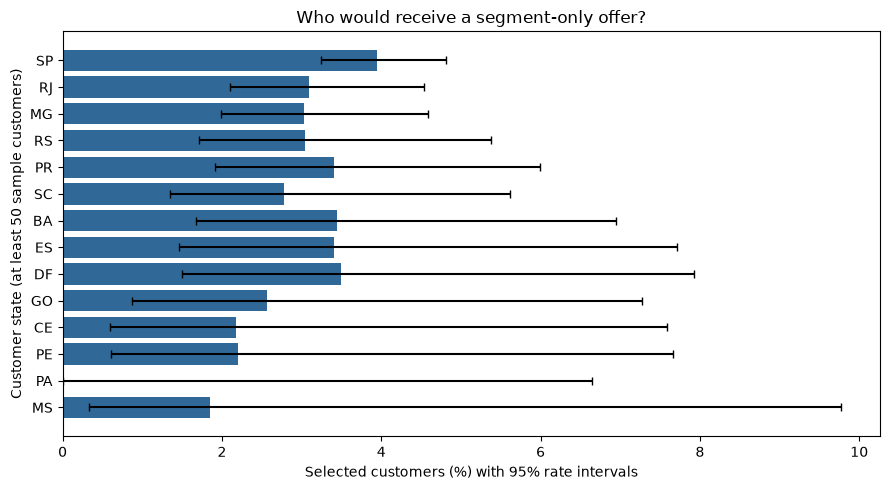

In [35]:
show_geographic_audit(bias_audit, figure_directory)

**Finding:** the state rate gap is **3.95 percentage points**, with a ratio of **0.00**. This is driven by PA having **0/54** selected customers, versus SP at **94/2,380**. PA's rate interval extends to about 6.64%, so zero in this sample does not establish zero opportunity in the population. The intervals also omit uncertainty from fitting and choosing the clusters. Investigate coverage before using segments to allocate offers.

### 5.5 Mitigations and decision

| Risk | Proposed action | How to check it |
| --- | --- | --- |
| Segment-only offers exclude customers | Keep basic service available to everyone; test inclusive outreach beyond the higher-spend segment. | Compare group reach and measured campaign benefit in an approved pilot. |
| Sparse groups or sales activity | Collect more representative real observations; test training-only reweighting if justified. Do not invent demographic labels or sales. | Recheck subgroup errors, sample sizes, and uncertainty on new dates. |
| Unreliable forecasts | Keep human review and the simple benchmark; test improvements using new validation dates. | Require improved error and trend agreement before operational use. |
| Missing sensitive attributes | If appropriate, obtain voluntarily supplied attributes with consent, restricted access, and a clear audit purpose. | Then assess protected-group selection rates and, with valid outcomes, equalised odds. |
| Unequal decision thresholds | If a real classifier or offer score is introduced, evaluate thresholds/post-processing on validation data. | Assess fairness and utility together; do not tune to this inspected test period. |

**Decision:** useful exploratory analysis, but insufficient evidence for automated offers or stocking decisions. Geographic differences warrant investigation; they do not establish discrimination. Proposed mitigations have not been deployed or shown to work. Only aggregate audit results are exported; protected-group coverage remains an explicit project gap.

In [36]:
# Derive the requested final-report section from this notebook and its results.
export_bias_report(bias_audit, project_root)

Saved reports/final_report.md: Bias & Fairness Analysis section.


<a id="step-6"></a>

# Step 6: Final Presentation & Communication

Two **10-slide** presentations are ready:

| Audience | PowerPoint | PDF |
| --- | --- | --- |
| Technical: peers | [Technical deck](../presentations/technical_deck.pptx) | [Technical PDF](../presentations/technical_deck.pdf) |
| Business: executives | [Business deck](../presentations/business_deck.pptx) | [Business PDF](../presentations/business_deck.pdf) |

The technical deck explains the data, models, evaluation and limitations. The business deck turns findings into proposed actions, an **illustrative ROI scenario**, risks and pilot success measures. Both include evidence references and speaker notes.

ROI is hypothetical; model gains and sensitive-group fairness are not claimed. The earlier repeat-purchase classification task remains retired.

[Regeneration and validation details](../presentations/README.md). See the [final report](../reports/final_report.md) for the combined findings. Protected-group fairness and mitigation effectiveness remain unverified.


<a id="step-7"></a>

# Step 7: GitHub Profile & Upload

The repository contains reusable code in `src/`, this single notebook, data acquisition instructions in `data/`, model regeneration instructions in `models/`, the final report, and both presentation decks. Raw data, fitted customer bundles, credentials and local environments are excluded.

See the [README](../README.md) for setup, reproduction commands and the publication status. GitHub upload is being prepared; a public link will be added after verification.


<a id="step-8"></a>

# Step 8: Earlier Fairness Placeholder

Explainability, limitations, the geographic disparity audit, and proposed mitigations are now in [Step 5](#step-5), following the assignment numbering. Sensitive-group fairness remains unmeasurable without suitable attributes.


<a id="step-9"></a>

# Conclusions and Reproducibility

K-Means describes two broad customer groups. The single-order group contributes most of the sample's recorded spending, so it should not be overlooked. Weekly and daily Random Forest forecasts do not beat their simple benchmarks; daily trend predictions match none of the five observed directions. These results support further investigation, not automated offers or stock decisions.

The [final report](../reports/final_report.md) combines framing, EDA, model results, fairness limits and recommendations. The [README](../README.md) provides commands to reproduce the notebook, regenerate saved models, and check temporal leakage and audit calculations. Presentation ROI is hypothetical.
